Load data

In [59]:
# BLOCK 0 — SETUP + AUTO FIND FILES
import os, re
from pathlib import Path
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

USE_VLE = True  # set False if you want to skip studentVle features

EXPECTED = {
    "assessments": "assessments.csv",
    "courses": "courses.csv",
    "studentAssessment": "studentAssessment.csv",
    "studentInfo": "studentInfo.csv",
    "studentRegistration": "studentRegistration.csv",
    "studentVle": "studentVle.csv",
    "vle": "vle.csv",
    "habits": "enhanced_student_habits_performance_dataset.csv",
}

CANDIDATE_ROOTS = [
    Path.cwd(),
    Path.cwd() / "data",
    Path("/mnt/data"),
]

def find_file(filename):
    filename = str(filename)
    for root in CANDIDATE_ROOTS:
        if not root.exists():
            continue
        p = root / filename
        if p.exists():
            return p
        # shallow search (2 levels)
        try:
            for d1 in root.iterdir():
                if d1.is_dir():
                    p1 = d1 / filename
                    if p1.exists():
                        return p1
                    for d2 in d1.iterdir():
                        if d2.is_dir():
                            p2 = d2 / filename
                            if p2.exists():
                                return p2
        except Exception:
            pass
    return None

FILES = {k: find_file(v) for k, v in EXPECTED.items()}
if not USE_VLE:
    FILES["studentVle"] = None
    FILES["vle"] = None

print("FILES FOUND:")
for k in EXPECTED:
    v = FILES.get(k)
    ok = (v is not None) and v.exists()
    print(f"  {k:>18}: {ok} — {str(v) if v else None}")

missing = [k for k, v in FILES.items() if v is None]
print("\nMISSING KEYS:", missing)
print("SEED:", SEED)


FILES FOUND:
         assessments: True — c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\assessments.csv
             courses: True — c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\courses.csv
   studentAssessment: True — c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\studentAssessment.csv
         studentInfo: True — c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\studentInfo.csv
  studentRegistration: True — c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\studentRegistration.csv
          studentVle: True — c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\studentVle.csv
                 vle: True — c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\vle.csv
              habits: True — c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\enhanced_student_habits_performance_dataset.csv

MISSING KEYS: []
SEED: 42


In [60]:
# BLOCK 1 — LOAD DATA
need = ["assessments","courses","studentAssessment","studentInfo","studentRegistration","habits"]
for k in need:
    assert FILES[k] is not None and FILES[k].exists(), f"Missing file: {k} ({EXPECTED[k]})"

assessments = pd.read_csv(FILES["assessments"])
courses = pd.read_csv(FILES["courses"])
studentAssessment = pd.read_csv(FILES["studentAssessment"])
studentInfo = pd.read_csv(FILES["studentInfo"])
studentRegistration = pd.read_csv(FILES["studentRegistration"])
habits = pd.read_csv(FILES["habits"])

if USE_VLE:
    assert FILES["studentVle"] is not None and FILES["studentVle"].exists(), "Missing studentVle.csv"
    assert FILES["vle"] is not None and FILES["vle"].exists(), "Missing vle.csv"
    studentVle = pd.read_csv(FILES["studentVle"], usecols=["code_module","code_presentation","id_student","id_site","date","sum_click"])
    vle = pd.read_csv(FILES["vle"], usecols=["code_module","code_presentation","id_site","activity_type"])
else:
    studentVle, vle = None, None

print("SHAPES:")
print("  assessments       :", assessments.shape)
print("  courses           :", courses.shape)
print("  studentAssessment :", studentAssessment.shape)
print("  studentInfo       :", studentInfo.shape)
print("  studentRegistration:", studentRegistration.shape)
print("  habits            :", habits.shape)
print("  studentVle        :", None if studentVle is None else studentVle.shape)
print("  vle               :", None if vle is None else vle.shape)

print("\nstudentInfo head:")
print(studentInfo.head(3))


ParserError: Error tokenizing data. C error: Calling read(nbytes) on source failed. Try engine='python'.

In [ ]:
# BLOCK 2 — OULAD CORE FEATURES + TARGET
#This block creates a clean OULAD dataset with a binary dropout-risk target and a few standardized fields, 
#plus placeholder columns so it can later be merged with your HABITS dataset without column mismatch.
si = studentInfo.copy()

# target: at_risk (Fail/Withdrawn)
si["at_risk"] = si["final_result"].astype(str).isin(["Fail","Withdrawn"]).astype(int)

# simple age mapping
age_map = {"0-35": 25, "35-55": 45, "55<=": 60}
si["age_years"] = si["age_band"].astype(str).map(age_map)

# standardized gender
si["gender_std"] = si["gender"].astype(str).replace({"M":"M","F":"F"}).fillna("Unknown")

# shared features
si["study_load"] = pd.to_numeric(si["studied_credits"], errors="coerce")
si["prior_perf"] = np.nan
si["attendance_metric"] = np.nan
si["dataset_source"] = "OULAD"

base_key = ["code_module","code_presentation","id_student"]
si = si.drop_duplicates(base_key).reset_index(drop=True)

print("OULAD CORE:", si.shape)
print("\nOULAD at_risk distribution:")
print(si["at_risk"].value_counts())
print("\nOULAD core sample:")
print(si[base_key + ["gender_std","age_years","study_load","final_result","at_risk"]].head(5))


OULAD CORE: (32593, 19)

OULAD at_risk distribution:
at_risk
1    17208
0    15385
Name: count, dtype: int64

OULAD core sample:
  code_module code_presentation  id_student gender_std  age_years  study_load final_result  at_risk
0         AAA             2013J       11391          M         60         240         Pass        0
1         AAA             2013J       28400          F         45          60         Pass        0
2         AAA             2013J       30268          F         45          60    Withdrawn        1
3         AAA             2013J       31604          F         45          60         Pass        0
4         AAA             2013J       32885          F         25          60         Pass        0


In [ ]:
# BLOCK 3 — OULAD ASSESSMENT FEATURES 
#This block produces assessment performance features (count, mean score, weighted score) per student per module/presentation,
# which you can later merge into your main OULAD “core” table to improve dropout prediction.
sa = studentAssessment.copy()
a = assessments.copy()

for c in ["weight","date"]:
    if c in a.columns:
        a[c] = pd.to_numeric(a[c], errors="coerce")

sa["score"] = pd.to_numeric(sa["score"], errors="coerce")
sa = sa.merge(a[["id_assessment","code_module","code_presentation","weight"]], on="id_assessment", how="left")

sa["score_x_weight"] = sa["score"].fillna(0) * sa["weight"].fillna(0)

ass_agg = (
    sa.groupby(base_key, as_index=False)
      .agg(
          n_assess=("score","count"),
          mean_score=("score","mean"),
          weighted_sum=("score_x_weight","sum"),
          weight_sum=("weight","sum"),
      )
)
ass_agg["weighted_score"] = ass_agg["weighted_sum"] / ass_agg["weight_sum"].replace(0, np.nan)
ass_agg = ass_agg.drop(columns=["weighted_sum","weight_sum"])

print("ass_agg:", ass_agg.shape)
print(ass_agg.head(5))
print("\nweighted_score describe:")
print(ass_agg["weighted_score"].describe())


ass_agg: (25843, 6)
  code_module code_presentation  id_student  n_assess  mean_score  weighted_score
0         AAA             2013J       11391         5        82.0            82.4
1         AAA             2013J       28400         5        66.4            65.4
2         AAA             2013J       31604         5        76.0            76.3
3         AAA             2013J       32885         5        54.4            55.0
4         AAA             2013J       38053         5        68.0            66.9

weighted_score describe:
count    23506.000000
mean        69.526300
std         16.961600
min          0.000000
25%         59.666667
50%         72.000000
75%         82.000000
max        100.000000
Name: weighted_score, dtype: float64


In [ ]:
# BLOCK 4 — OULAD VLE FEATURES 
#This block turns raw OULAD online activity logs into 3 useful engagement features (total clicks, active days, unique sites) per student per course run,
# which helps predict dropout risk because engagement is strongly linked to success.

if USE_VLE:
    sv = studentVle.copy()
    sv["sum_click"] = pd.to_numeric(sv["sum_click"], errors="coerce").fillna(0)
    sv["date"] = pd.to_numeric(sv["date"], errors="coerce")

    # total clicks + active days + unique sites
    vle_agg = (
        sv.groupby(base_key, as_index=False)
          .agg(
              total_clicks=("sum_click","sum"),
              active_days=("date", lambda x: x.nunique()),
              unique_sites=("id_site", lambda x: x.nunique()),
          )
    )

    print("vle_agg:", vle_agg.shape)
    print(vle_agg.head(5))
else:
    vle_agg = None
    print("VLE SKIPPED")


vle_agg: (29228, 6)
  code_module code_presentation  id_student  total_clicks  active_days  unique_sites
0         AAA             2013J       11391           934           40            55
1         AAA             2013J       28400          1435           80            84
2         AAA             2013J       30268           281           12            22
3         AAA             2013J       31604          2158          123            82
4         AAA             2013J       32885          1034           70            66


In [ ]:
# BLOCK 5 — MERGE OULAD FEATURES
#This block builds the final OULAD feature table by merging student info + assessment performance + (optional) VLE engagement, 
#then maps OULAD behavior into common fields (prior_perf, attendance_metric) so it can be combined smoothly with your HABITS dataset later.
oulad = si.merge(ass_agg, on=base_key, how="left")
if USE_VLE:
    oulad = oulad.merge(vle_agg, on=base_key, how="left")

# define shared fields from OULAD behavior
oulad["prior_perf"] = oulad["weighted_score"]
oulad["attendance_metric"] = oulad["total_clicks"] if "total_clicks" in oulad.columns else np.nan

print("OULAD FINAL:", oulad.shape)
print("\nOULAD missing top 10:")
print(oulad.isna().mean().sort_values(ascending=False).head(10))
print("\nOULAD sample:")
show_cols = base_key + ["dataset_source","at_risk","gender_std","age_years","study_load","prior_perf","attendance_metric","n_assess","mean_score","weighted_score"]
show_cols = [c for c in show_cols if c in oulad.columns]
print(oulad[show_cols].head(5))


OULAD FINAL: (32593, 25)

OULAD missing top 10:
prior_perf              0.278802
weighted_score          0.278802
mean_score              0.207805
n_assess                0.207100
attendance_metric       0.103243
active_days             0.103243
total_clicks            0.103243
unique_sites            0.103243
imd_band                0.034087
num_of_prev_attempts    0.000000
dtype: float64

OULAD sample:
  code_module code_presentation  id_student dataset_source  at_risk gender_std  age_years  study_load  prior_perf  attendance_metric  n_assess  mean_score  weighted_score
0         AAA             2013J       11391          OULAD        0          M         60         240        82.4              934.0       5.0        82.0            82.4
1         AAA             2013J       28400          OULAD        0          F         45          60        65.4             1435.0       5.0        66.4            65.4
2         AAA             2013J       30268          OULAD        1          F 

In [ ]:
# BLOCK 6 — HABITS CLEAN + SHARED FEATURES + TARGET 
#This block cleans the habits dataset, standardizes column names and gender, creates the binary target at_risk, 
#builds shared features (study_load, prior_perf, attendance_metric), and adds OULAD-like keys so it can be safely merged with OULAD later.
hb = habits.copy()

def snake(s):
    s = re.sub(r"[^0-9a-zA-Z_]+", "_", str(s)).strip("_")
    s = re.sub(r"_+", "_", s)
    return s.lower()

hb.columns = [snake(c) for c in hb.columns]

hb["dataset_source"] = "HABITS"

hb["gender_std"] = hb["gender"].astype(str).str.lower().replace({
    "male":"M","m":"M","female":"F","f":"F"
}).fillna("Unknown")

hb["age_years"] = pd.to_numeric(hb["age"], errors="coerce")

hb["at_risk"] = hb["dropout_risk"].astype(str).str.lower().eq("yes").astype(int)

hb["study_load"] = pd.to_numeric(hb["study_hours_per_day"], errors="coerce") * 7.0
hb["prior_perf"] = pd.to_numeric(hb["previous_gpa"], errors="coerce")
hb["attendance_metric"] = pd.to_numeric(hb["attendance_percentage"], errors="coerce")

# extra feature
hb["entertainment_hours"] = (
    pd.to_numeric(hb["social_media_hours"], errors="coerce").fillna(0) +
    pd.to_numeric(hb["netflix_hours"], errors="coerce").fillna(0)
)

# create OULAD-like keys for consistent schema
hb["code_module"] = "HABITS"
hb["code_presentation"] = "NA"
hb["id_student"] = pd.to_numeric(hb["student_id"], errors="coerce").fillna(-1).astype(int)

print("HABITS READY:", hb.shape)
print("\nHABITS at_risk distribution:")
print(hb["at_risk"].value_counts())
print("\nHABITS sample:")
print(hb[["id_student","dataset_source","gender_std","age_years","study_load","prior_perf","attendance_metric","entertainment_hours","at_risk"]].head(5))


HABITS READY: (80000, 42)

HABITS at_risk distribution:
at_risk
0    78418
1     1582
Name: count, dtype: int64

HABITS sample:
   id_student dataset_source gender_std  age_years  study_load  prior_perf  attendance_metric  entertainment_hours  at_risk
0      100000         HABITS          M         26   53.517566        4.00               70.3                  3.1        0
1      100001         HABITS          M         28   39.900000        4.00               88.4                  0.9        0
2      100002         HABITS          M         17   16.800000        3.79               82.1                  4.9        0
3      100003         HABITS      other         27   23.800000        4.00               79.3                  6.9        0
4      100004         HABITS          F         25   32.900000        4.00               62.9                  3.5        0


In [ ]:
# BLOCK 7 — HARMONIZE + COMBINE (OULAD + HABITS)  

drop_oulad = [c for c in ["final_result","gender","disability","age_band"] if c in oulad.columns]
drop_habits = [c for c in ["gender","dropout_risk","age","student_id"] if c in hb.columns]

oulad2 = oulad.drop(columns=drop_oulad).copy()
hb2 = hb.drop(columns=drop_habits).copy()

# Align columns (union)
all_cols = sorted(set(oulad2.columns) | set(hb2.columns))
oulad2 = oulad2.reindex(columns=all_cols)
hb2 = hb2.reindex(columns=all_cols)

combined = pd.concat([oulad2, hb2], ignore_index=True)

# clean types
combined["at_risk"] = combined["at_risk"].astype(int)
combined["gender_std"] = combined["gender_std"].astype(str).fillna("Unknown")
combined["dataset_source"] = combined["dataset_source"].astype(str)

print("COMBINED:", combined.shape)
print("\nSOURCES:")
print(combined["dataset_source"].value_counts())
print("\nCOMBINED at_risk distribution:")
print(combined["at_risk"].value_counts())
print("\nCOMBINED sample:")
print(combined[["dataset_source","gender_std","age_years","study_load","prior_perf","attendance_metric","at_risk"]].head(8))


COMBINED: (112593, 49)

SOURCES:
dataset_source
HABITS    80000
OULAD     32593
Name: count, dtype: int64

COMBINED at_risk distribution:
at_risk
0    93803
1    18790
Name: count, dtype: int64

COMBINED sample:
  dataset_source gender_std  age_years  study_load  prior_perf  attendance_metric  at_risk
0          OULAD          M         60       240.0        82.4              934.0        0
1          OULAD          F         45        60.0        65.4             1435.0        0
2          OULAD          F         45        60.0         NaN              281.0        1
3          OULAD          F         45        60.0        76.3             2158.0        0
4          OULAD          F         25        60.0        55.0             1034.0        0
5          OULAD          M         45        60.0        66.9             2445.0        0
6          OULAD          M         25        60.0        67.8             1492.0        0
7          OULAD          F         25       120.0        72

Data understanding

In [ ]:
# EDA BLOCK 1/10 — NICE VISUAL STYLE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import is_numeric_dtype

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.figsize": (8, 4),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.grid": True,
    "grid.alpha": 0.20,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

def _label_bars(ax, fmt="{:,.0f}"):
    for p in ax.patches:
        w = p.get_width()
        if np.isfinite(w) and w > 0:
            ax.text(w, p.get_y() + p.get_height()/2, "  " + fmt.format(w), va="center", ha="left", fontsize=9)

def barh_top_counts(series, top=12, title="", xlabel="Count"):
    s = series.astype("string").fillna("NA")
    vc = s.value_counts(dropna=False).head(top)[::-1]
    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.35*len(vc)+1)))
    vc.plot(kind="barh", ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    _label_bars(ax)
    plt.tight_layout()
    plt.show()
    return vc

def stacked_proportion_plot(tab, title="", xlabel="Category"):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    tab.plot(kind="bar", stacked=True, ax=ax)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Proportion")
    ax.legend(title="at_risk", loc="upper right")
    plt.tight_layout()
    plt.show()

df = combined
target_col = "at_risk"
source_col = "dataset_source"

num_cols = [c for c in df.columns if is_numeric_dtype(df[c]) and c != target_col]
cat_cols = [c for c in df.columns if (not is_numeric_dtype(df[c])) and c != target_col]

print("EDA STYLE READY")
print("shape:", df.shape, "| numeric:", len(num_cols), "| categorical:", len(cat_cols))


EDA STYLE READY
shape: (112593, 49) | numeric: 31 | categorical: 17


In [ ]:
# EDA BLOCK 2/10 — OVERVIEW (STRUCTURE + TYPES + TARGET)
print("\n" + "="*70)
print("EDA 2/10 — OVERVIEW")
print("="*70)

print("shape:", df.shape)
df.info()
print("columns:", len(df.columns))
print("\nhead:")
print(df.head(3))

print("\ndtypes summary:")
print(df.dtypes.value_counts())

print("\nTarget distribution:")
print(df[target_col].value_counts(dropna=False))

if source_col in df.columns:
    print("\nSource distribution:")
    print(df[source_col].value_counts(dropna=False))



EDA 2/10 — OVERVIEW
shape: (112593, 49)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112593 entries, 0 to 112592
Data columns (total 49 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   access_to_tutoring             80000 non-null   object 
 1   active_days                    29228 non-null   float64
 2   age_years                      112593 non-null  int64  
 3   at_risk                        112593 non-null  int64  
 4   attendance_metric              109228 non-null  float64
 5   attendance_percentage          80000 non-null   float64
 6   code_module                    112593 non-null  object 
 7   code_presentation              112593 non-null  object 
 8   dataset_source                 112593 non-null  object 
 9   diet_quality                   80000 non-null   object 
 10  entertainment_hours            80000 non-null   float64
 11  exam_anxiety_score             80000 non-null   fl


EDA 3/10 — DATA QUALITY

Top missing-rate columns (>0):
weighted_score                   0.791230
mean_score                       0.770678
n_assess                         0.770474
total_clicks                     0.740410
unique_sites                     0.740410
active_days                      0.740410
imd_band                         0.720391
highest_education                0.710524
num_of_prev_attempts             0.710524
studied_credits                  0.710524
region                           0.710524
access_to_tutoring               0.289476
attendance_percentage            0.289476
exam_score                       0.289476
exam_anxiety_score               0.289476
extracurricular_participation    0.289476
exercise_frequency               0.289476
study_environment                0.289476
previous_gpa                     0.289476
parental_support_level           0.289476
part_time_job                    0.289476
netflix_hours                    0.289476
screen_time        

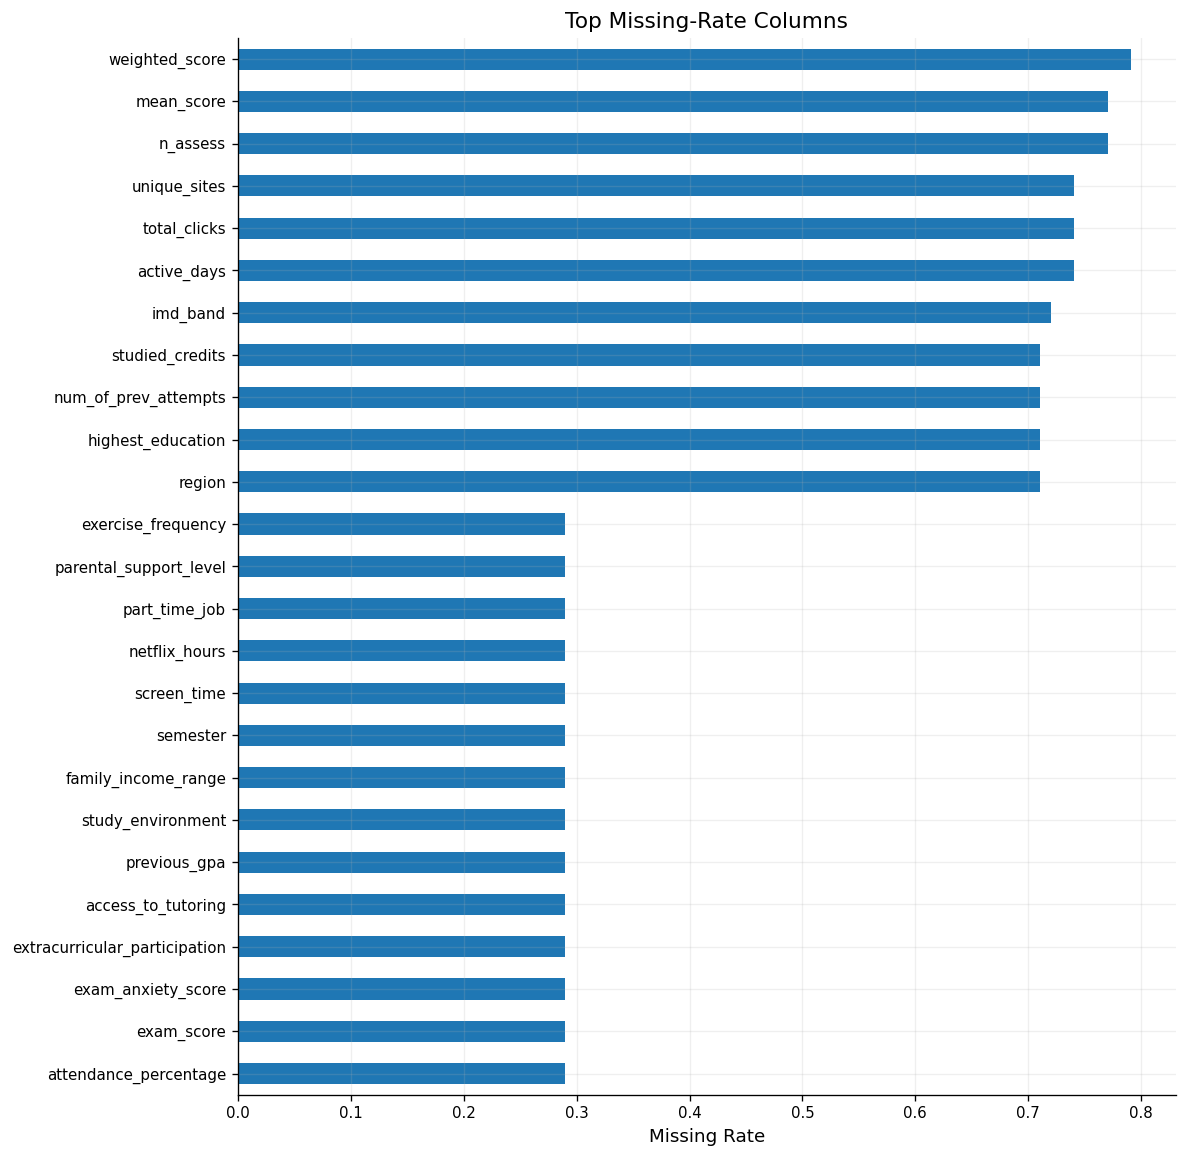


Duplicate rate on ['dataset_source', 'code_module', 'code_presentation', 'id_student'] : 0.0

Quick numeric ranges:
  age_years            min=16.000  max=60.000  mean=24.614
  study_load           min=0.000  max=655.000  mean=43.850
  prior_perf           min=0.000  max=100.000  mean=18.574
  attendance_metric    min=1.000  max=24139.000  mean=413.836
  weighted_score       min=0.000  max=100.000  mean=69.526
  mean_score           min=0.000  max=100.000  mean=72.768
  n_assess             min=0.000  max=14.000  mean=6.723
  total_clicks         min=1.000  max=24139.000  mean=1355.040
  active_days          min=1.000  max=286.000  mean=61.863
  unique_sites         min=1.000  max=413.000  mean=67.076
  entertainment_hours  min=0.000  max=9.000  mean=4.499


In [ ]:
# EDA BLOCK 3/10 — DATA QUALITY (MISSING + DUPLICATES + QUICK RANGE)
print("\n" + "="*70)
print("EDA 3/10 — DATA QUALITY")
print("="*70)

missing_rate = df.isna().mean().sort_values(ascending=False)
missing_top = missing_rate[missing_rate > 0].head(25)

print("\nTop missing-rate columns (>0):")
print(missing_top if len(missing_top) else "No missing values")

if len(missing_top) > 0:
    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.35*len(missing_top)+1)))
    missing_top.sort_values().plot(kind="barh", ax=ax)
    ax.set_title("Top Missing-Rate Columns")
    ax.set_xlabel("Missing Rate")
    plt.tight_layout()
    plt.show()

id_cols = [c for c in ["dataset_source","code_module","code_presentation","id_student"] if c in df.columns]
if len(id_cols) >= 2:
    print("\nDuplicate rate on", id_cols, ":", df.duplicated(id_cols).mean())
else:
    print("\nDuplicate check skipped (not enough id columns).")

check_cols = [c for c in ["age_years","study_load","prior_perf","attendance_metric","weighted_score","mean_score",
                          "n_assess","total_clicks","active_days","unique_sites","entertainment_hours"]
              if c in df.columns and is_numeric_dtype(df[c])]

print("\nQuick numeric ranges:")
for c in check_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    print(f"  {c:<20} min={np.nanmin(s.values):.3f}  max={np.nanmax(s.values):.3f}  mean={np.nanmean(s.values):.3f}")



EDA 4/10 — TARGET + SOURCE


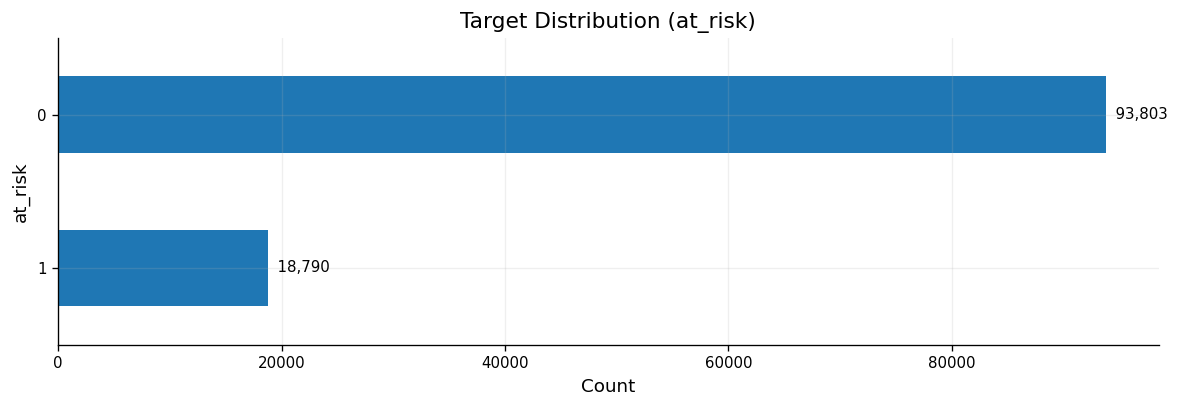

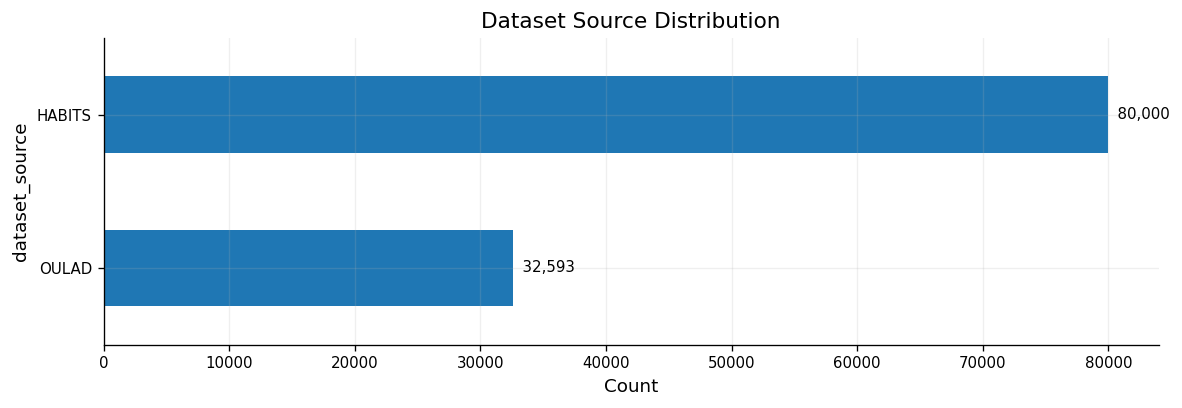


At-risk rate by dataset_source:
dataset_source
OULAD     0.527966
HABITS    0.019775
Name: at_risk, dtype: float64


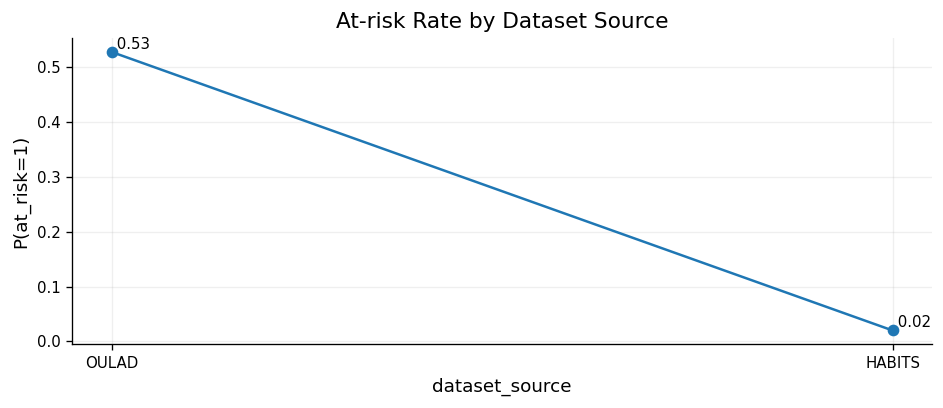

In [ ]:
# EDA BLOCK 4/10 — TARGET + SOURCE (CLEAN, READABLE)
print("\n" + "="*70)
print("EDA 4/10 — TARGET + SOURCE")
print("="*70)

barh_top_counts(df[target_col], top=10, title="Target Distribution (at_risk)", xlabel="Count")

if source_col in df.columns:
    barh_top_counts(df[source_col], top=10, title="Dataset Source Distribution", xlabel="Count")

    rate = df.groupby(source_col)[target_col].mean().sort_values(ascending=False)
    print("\nAt-risk rate by dataset_source:")
    print(rate)

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.plot(range(len(rate)), rate.values, marker="o")
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels(rate.index.astype(str), rotation=0)
    ax.set_title("At-risk Rate by Dataset Source")
    ax.set_xlabel(source_col)
    ax.set_ylabel("P(at_risk=1)")
    for i, v in enumerate(rate.values):
        ax.text(i, v, f" {v:.2f}", va="bottom", fontsize=9)
    plt.tight_layout()
    plt.show()



EDA 5/10 — UNIVARIATE NUMERIC (BASIC + COLOURS)
Numeric columns shown: ['age_years', 'study_load', 'prior_perf', 'attendance_metric', 'weighted_score', 'mean_score', 'n_assess', 'total_clicks', 'active_days', 'unique_sites', 'entertainment_hours']


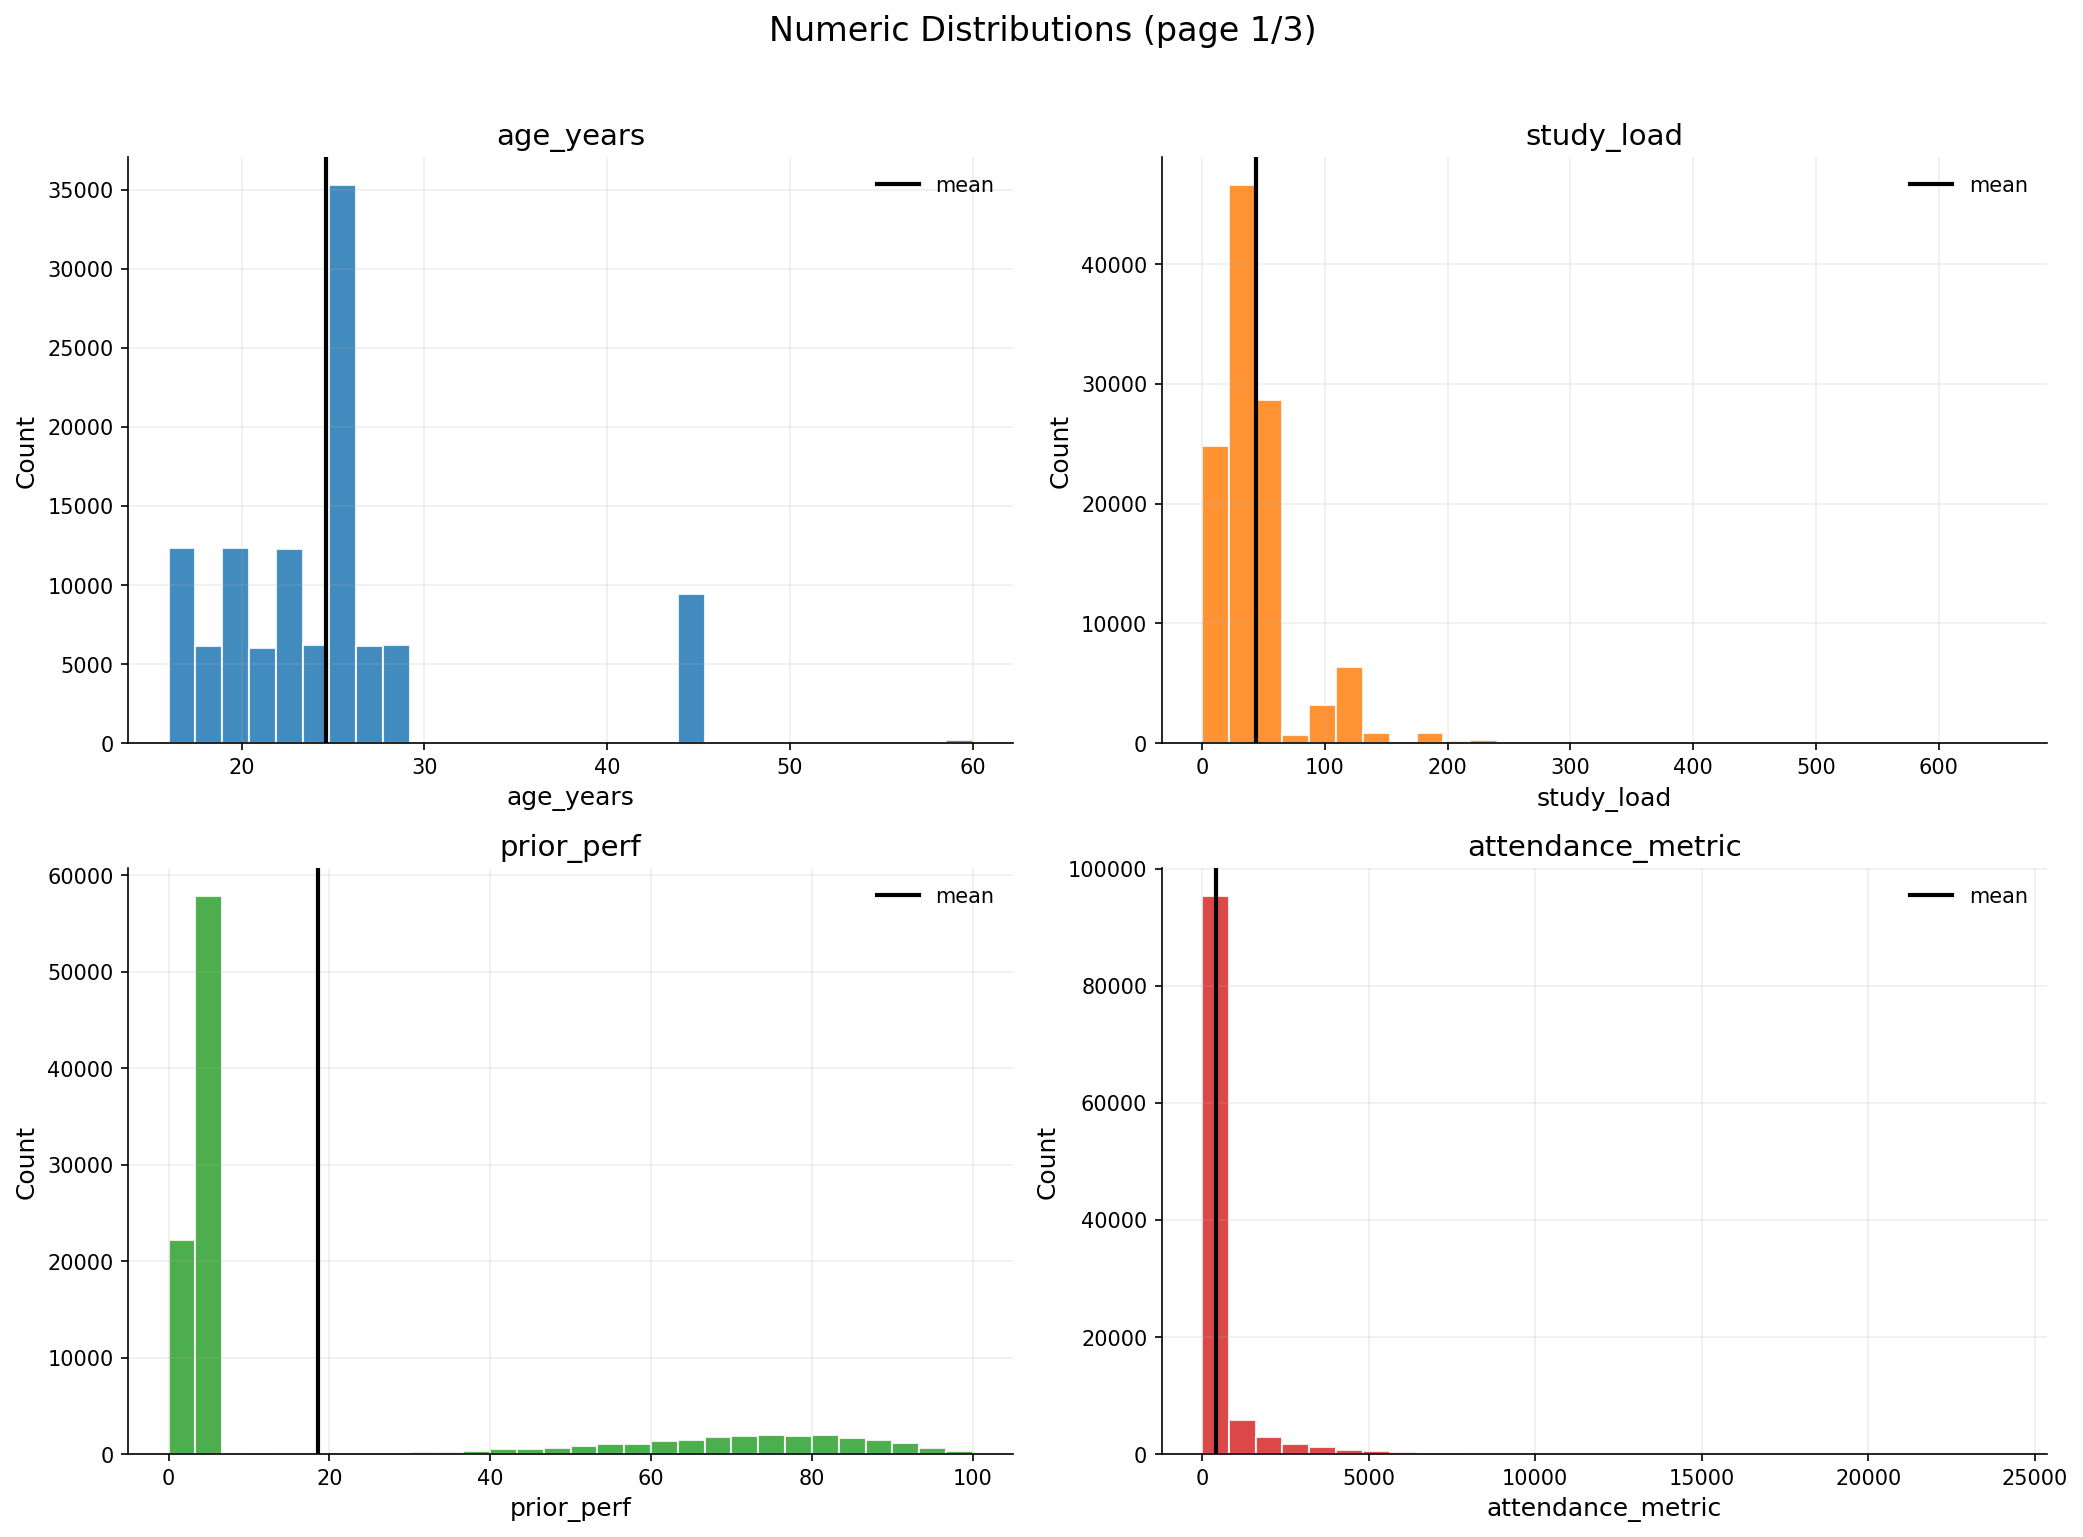

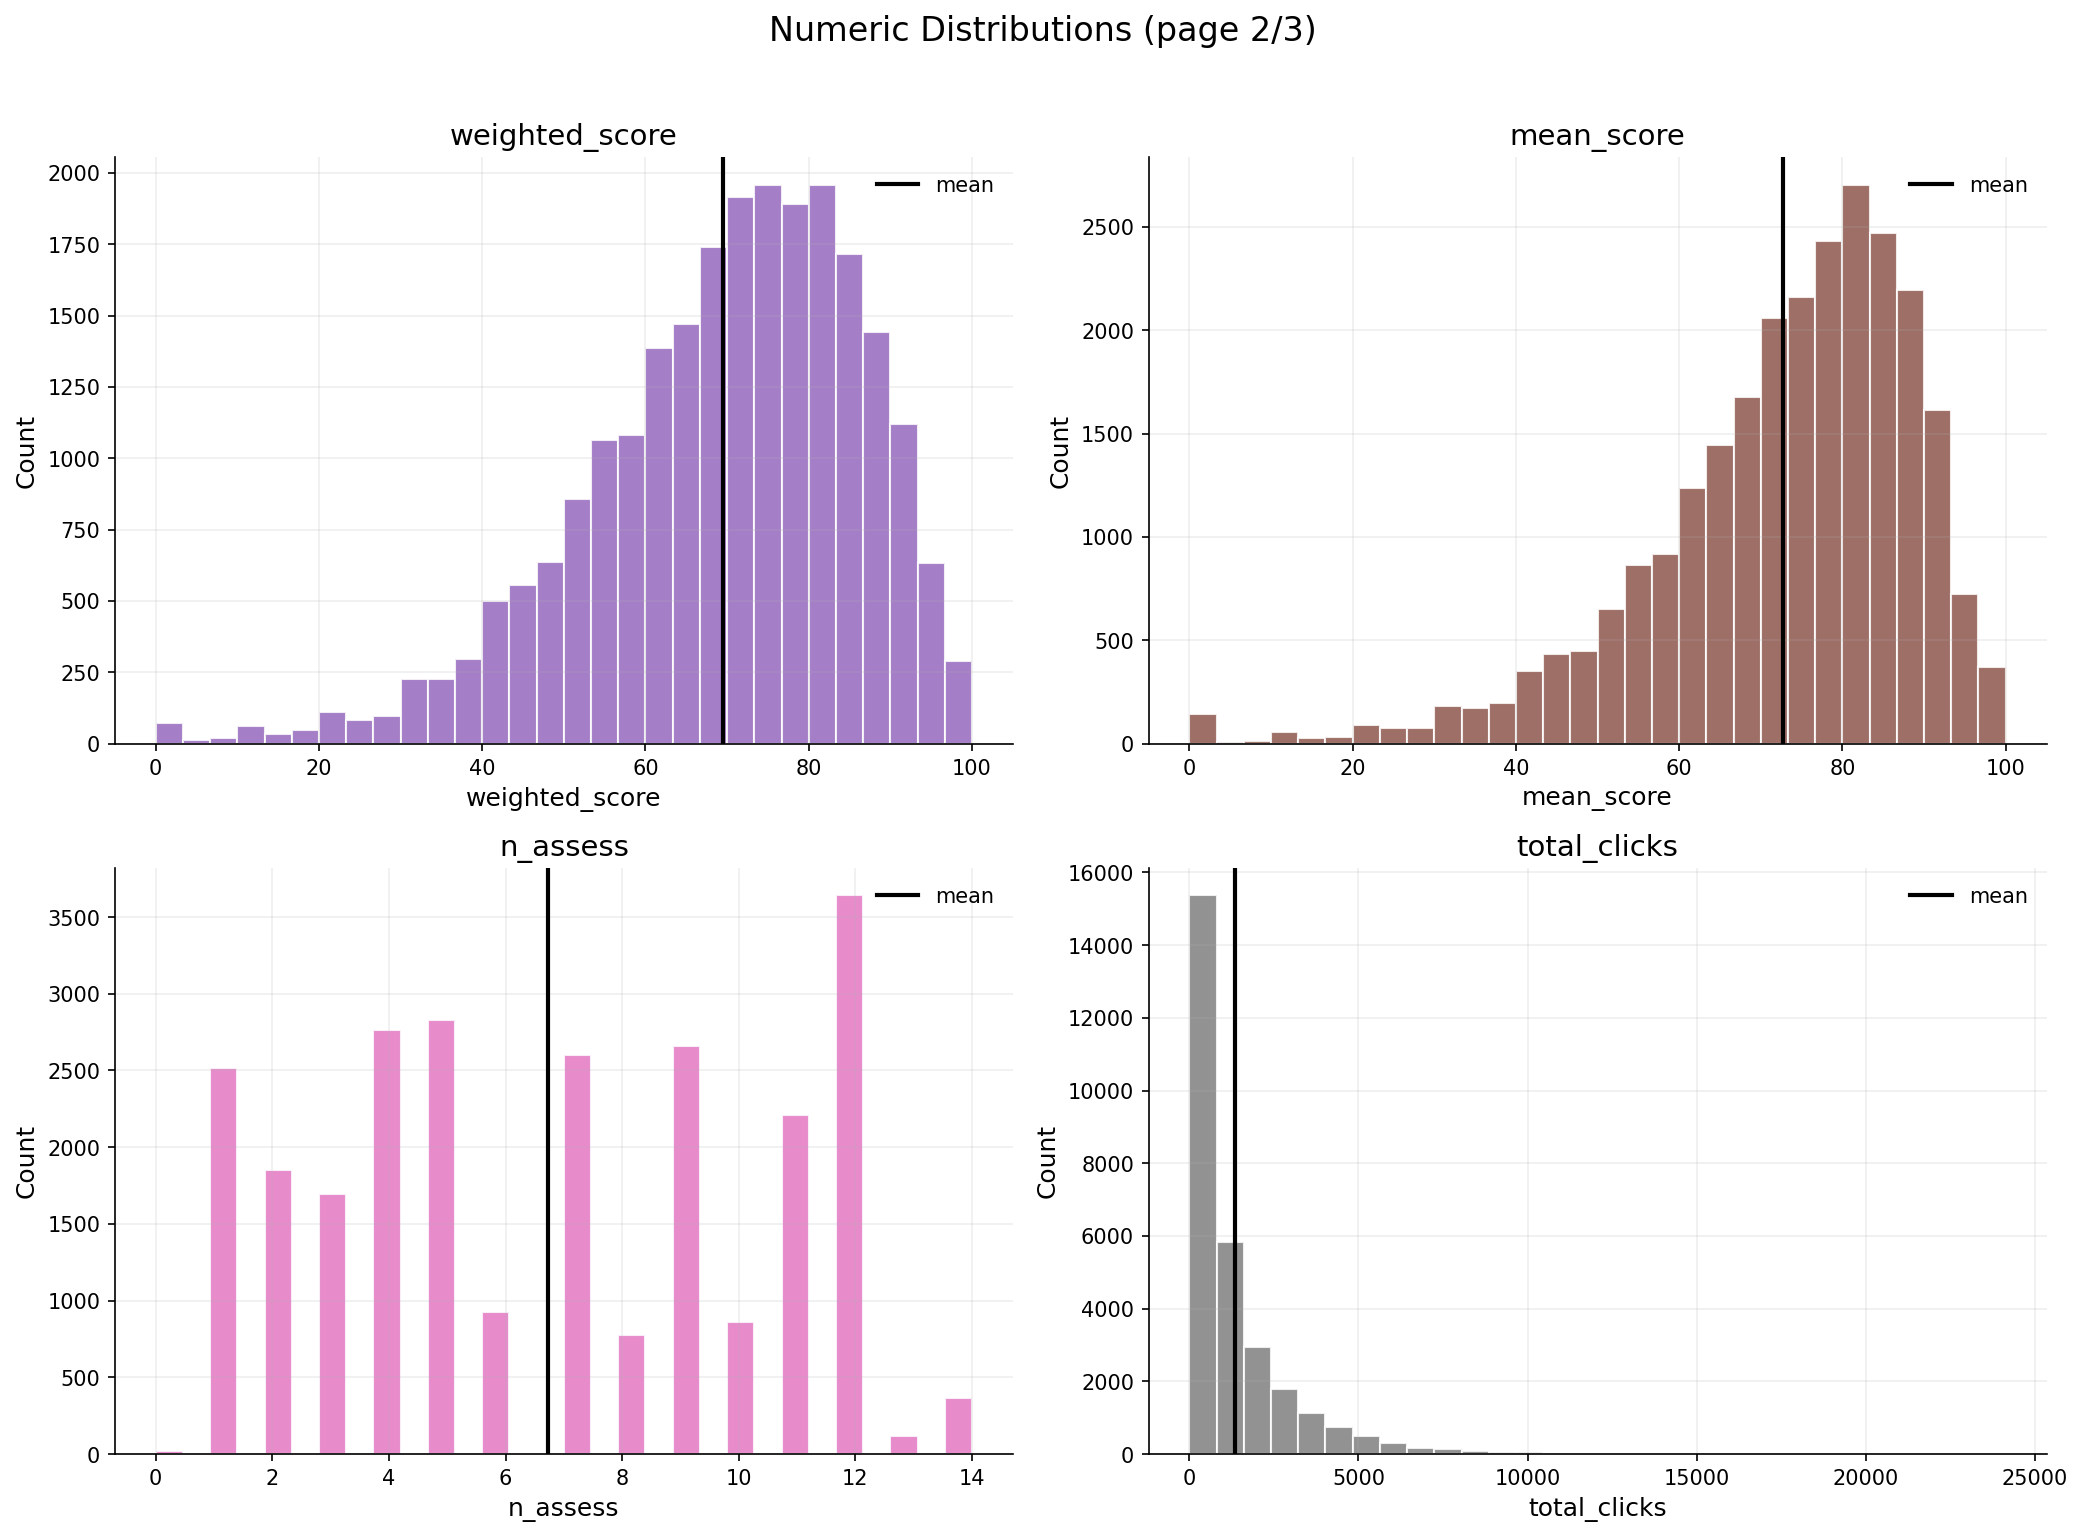

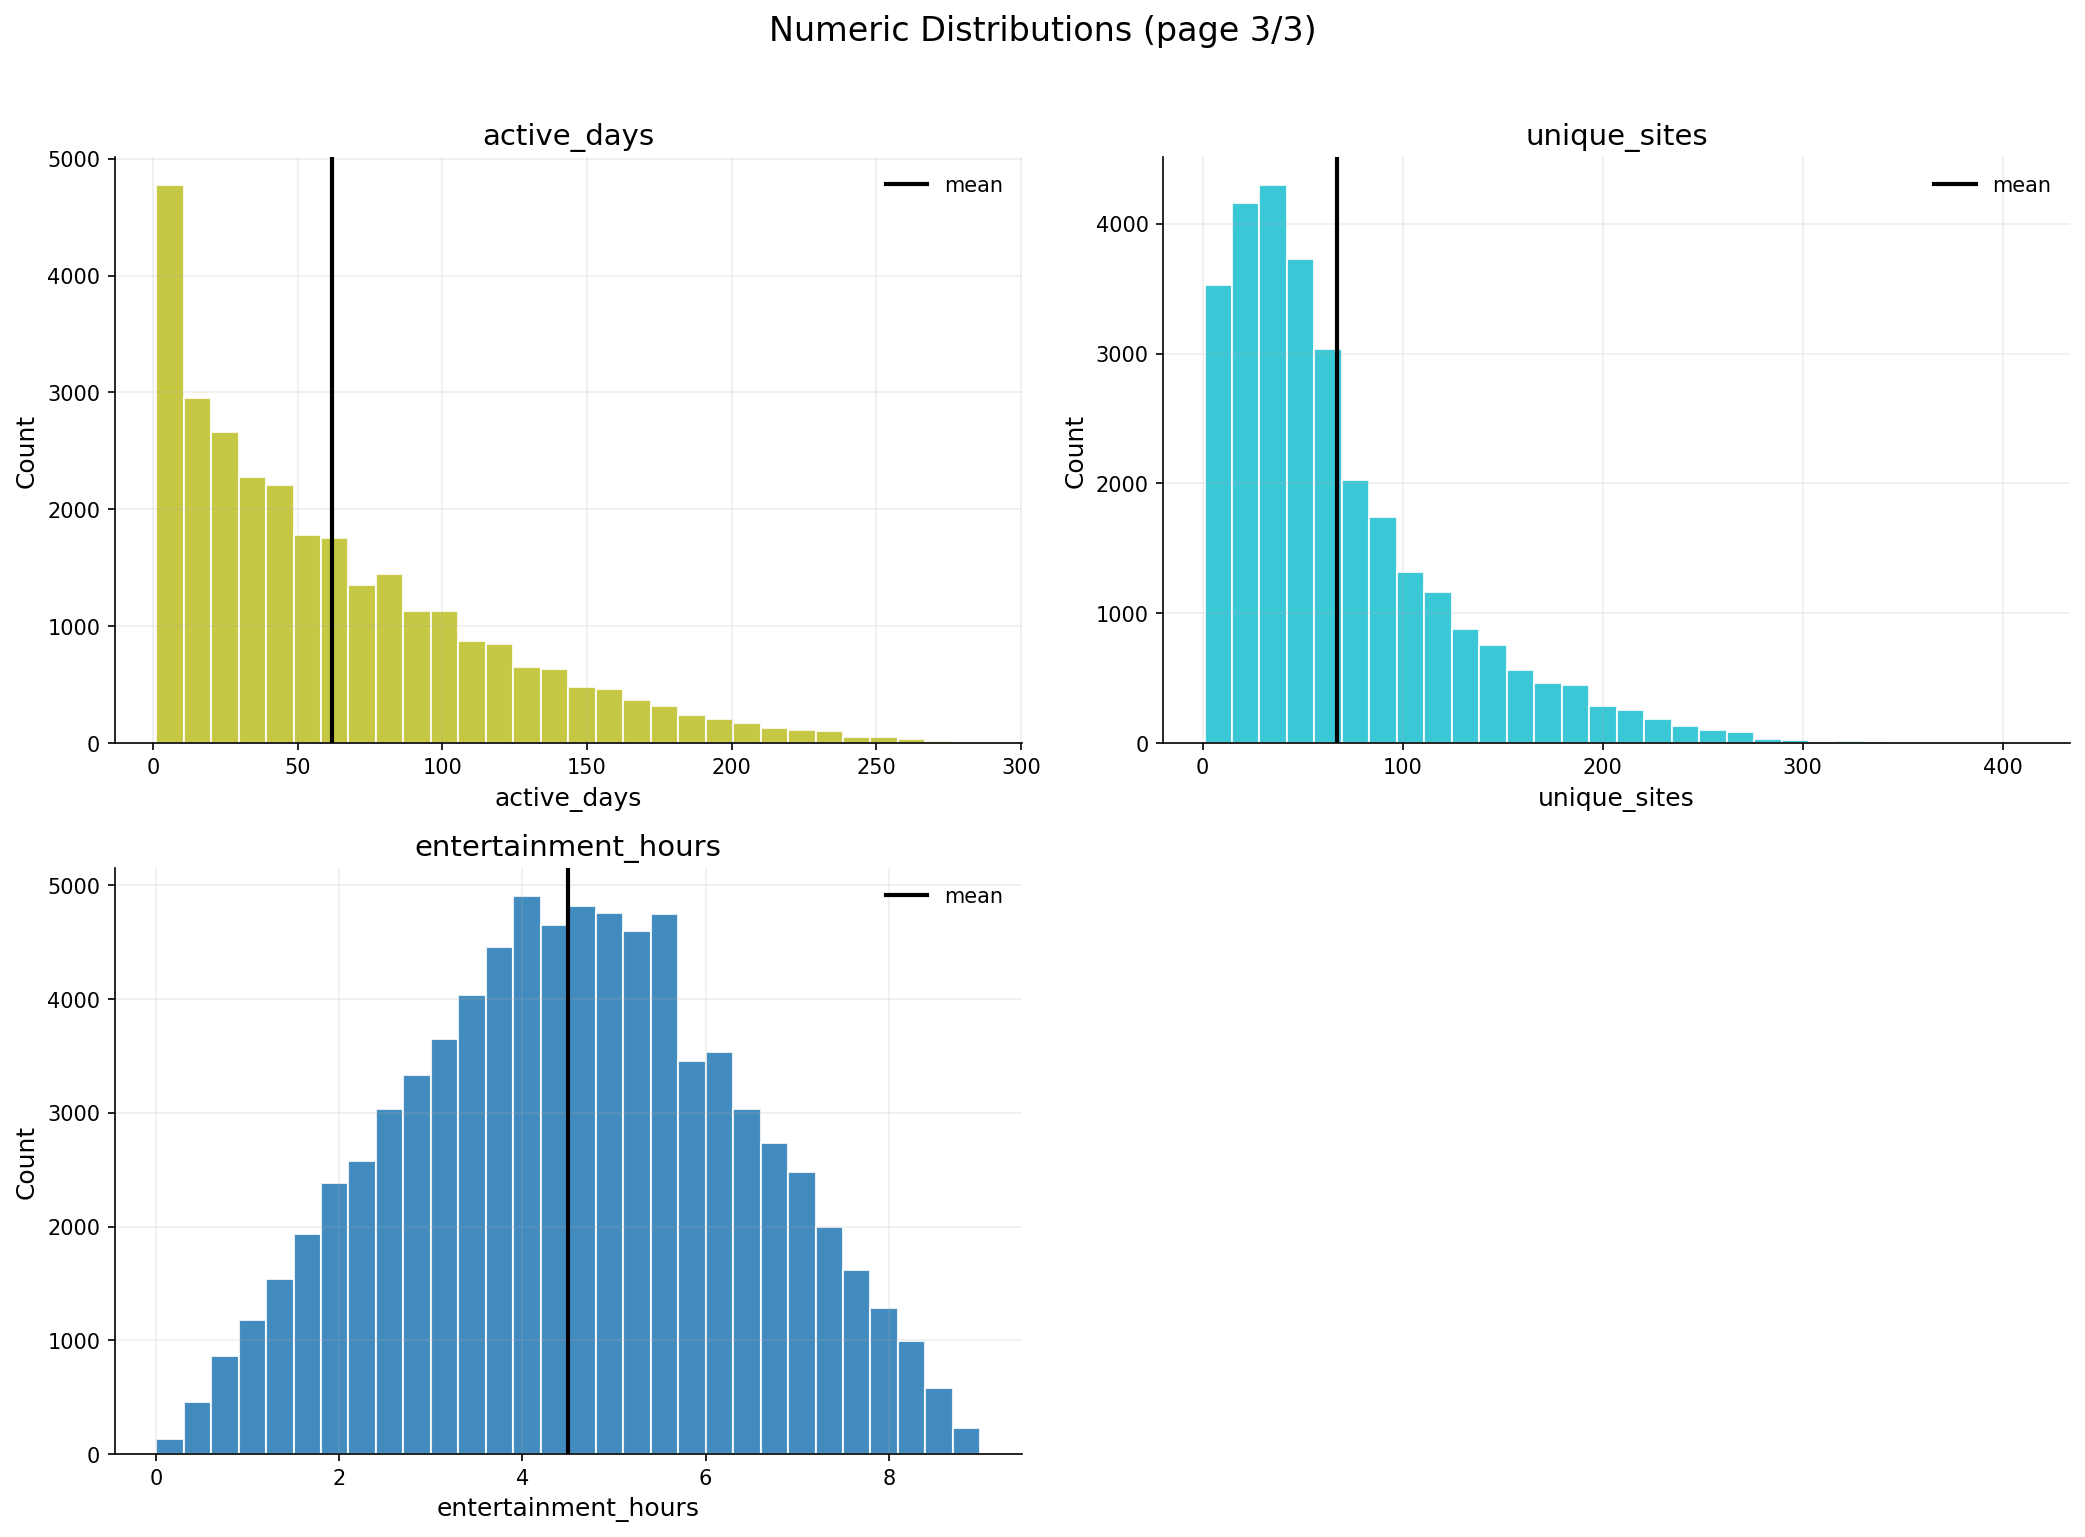

In [ ]:
# EDA BLOCK 5/10 — UNIVARIATE NUMERIC (BASIC + DIFFERENT COLOURS)
print("\n" + "="*70)
print("EDA 5/10 — UNIVARIATE NUMERIC (BASIC + COLOURS)")
print("="*70)

preferred = [
    "age_years","study_load","prior_perf","attendance_metric",
    "weighted_score","mean_score","n_assess",
    "total_clicks","active_days","unique_sites",
    "entertainment_hours"
]

present = [c for c in preferred if c in df.columns and is_numeric_dtype(df[c])]
num_show = present.copy()
if len(num_show) < 9:
    num_show += [c for c in num_cols if c not in num_show][: (12-len(num_show))]

print("Numeric columns shown:", num_show)

plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.2,
})

colors = ["tab:blue","tab:orange","tab:green","tab:red","tab:purple","tab:brown","tab:pink","tab:gray","tab:olive","tab:cyan"]

plots_per_page = 4
pages = int(np.ceil(len(num_show) / plots_per_page))

for p in range(pages):
    subset = num_show[p*plots_per_page : (p+1)*plots_per_page]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.reshape(-1)

    for i, c in enumerate(subset):
        ax = axes[i]
        s = pd.to_numeric(df[c], errors="coerce").dropna()

        color = colors[(p*plots_per_page + i) % len(colors)]
        ax.hist(s, bins=30, color=color, alpha=0.85, edgecolor="white")

        if len(s) > 0:
            ax.axvline(s.mean(), linewidth=2, color="black", label="mean")
            ax.legend(frameon=False)

        ax.set_title(c)
        ax.set_xlabel(c)
        ax.set_ylabel("Count")

    for j in range(len(subset), 4):
        axes[j].axis("off")

    fig.suptitle(f"Numeric Distributions (page {p+1}/{pages})", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()



EDA 6/10 — NUMERIC SPREAD/OUTLIERS (BOXPLOT)
Columns: ['age_years', 'study_load', 'prior_perf', 'attendance_metric', 'weighted_score', 'mean_score', 'n_assess', 'total_clicks']


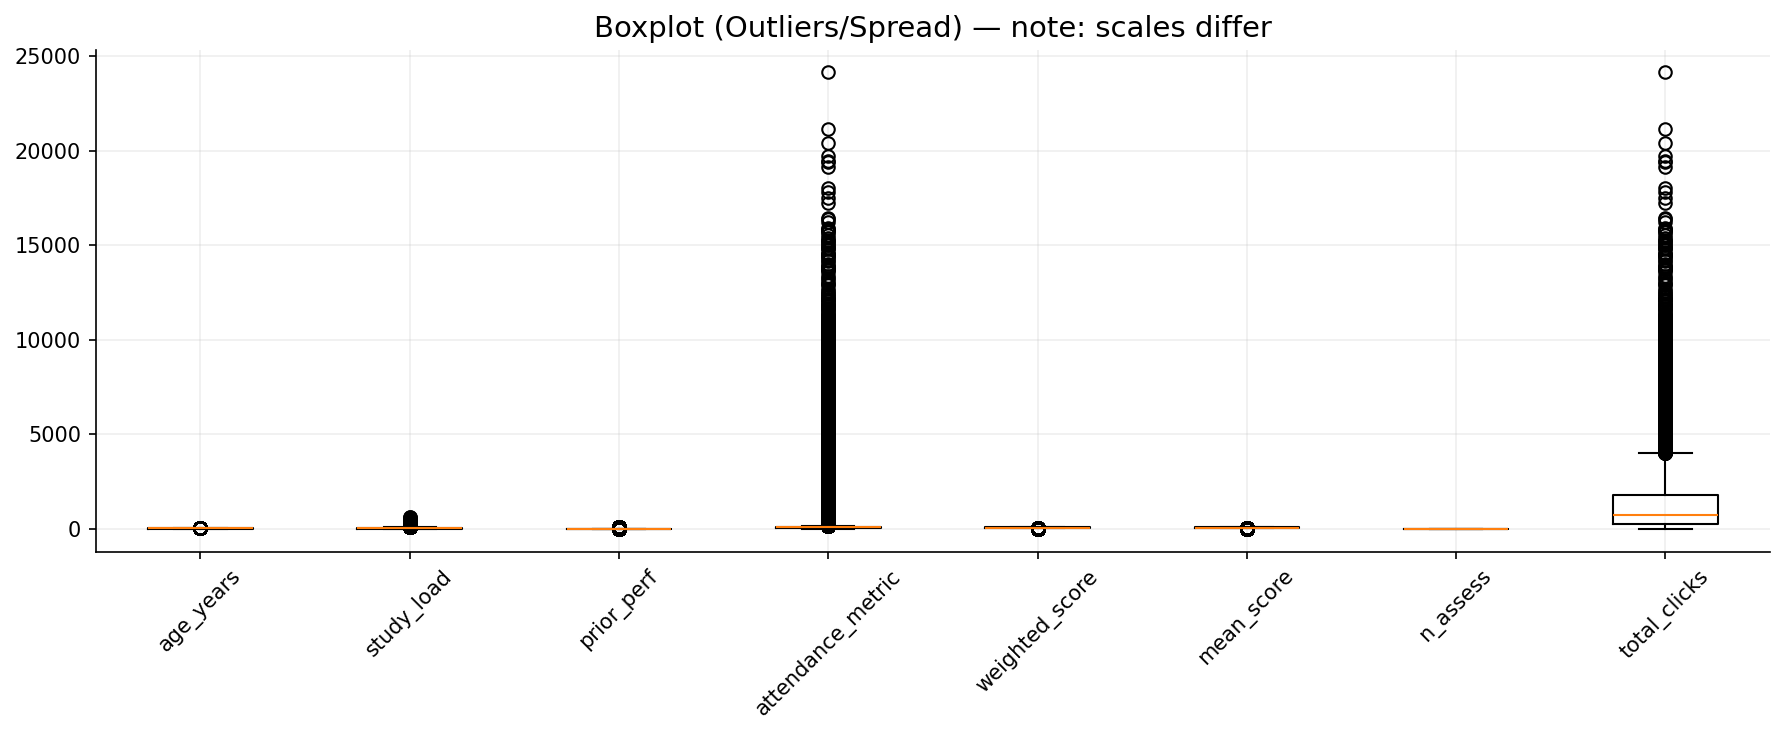

In [ ]:
#BLOCK 6 — MULTI-FEATURE BOXPLOT
print("\n" + "="*70)
print("EDA 6/10 — NUMERIC SPREAD/OUTLIERS (BOXPLOT)")
print("="*70)

num_show2 = num_show[:8] if len(num_show) else num_cols[:8]
print("Columns:", num_show2)

data = [pd.to_numeric(df[c], errors="coerce").dropna().values for c in num_show2]

plt.rcParams.update({"figure.dpi": 150})

fig, ax = plt.subplots(figsize=(12, 5))
ax.boxplot(data, tick_labels=num_show2, vert=True, showfliers=True)
ax.set_title("Boxplot (Outliers/Spread) — note: scales differ")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()



EDA 7/10 — UNIVARIATE CATEGORICAL
Categorical columns shown: ['dataset_source', 'gender_std', 'highest_education', 'imd_band', 'region']

dataset_source top levels:
dataset_source
HABITS    80000
OULAD     32593
Name: count, dtype: Int64


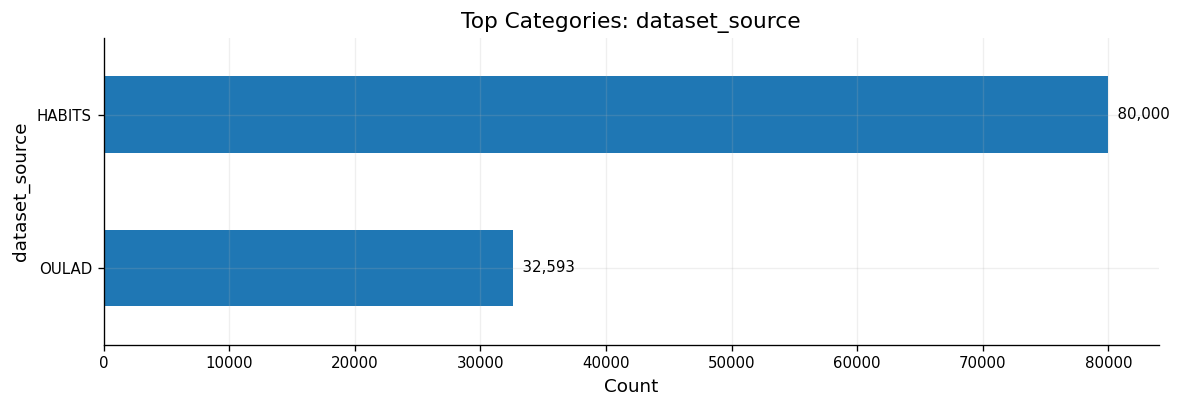


gender_std top levels:
gender_std
M        44573
F        41423
other    26597
Name: count, dtype: Int64


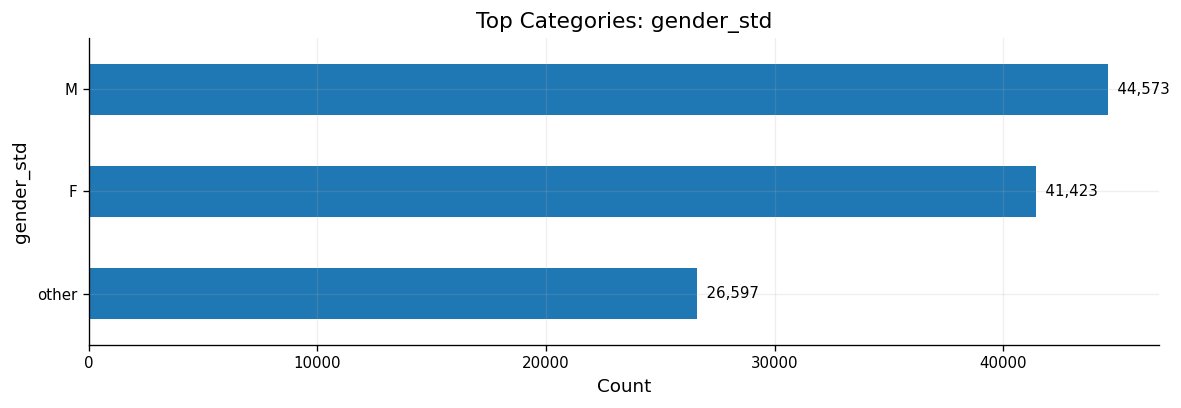


highest_education top levels:
highest_education
NA                             80000
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: Int64


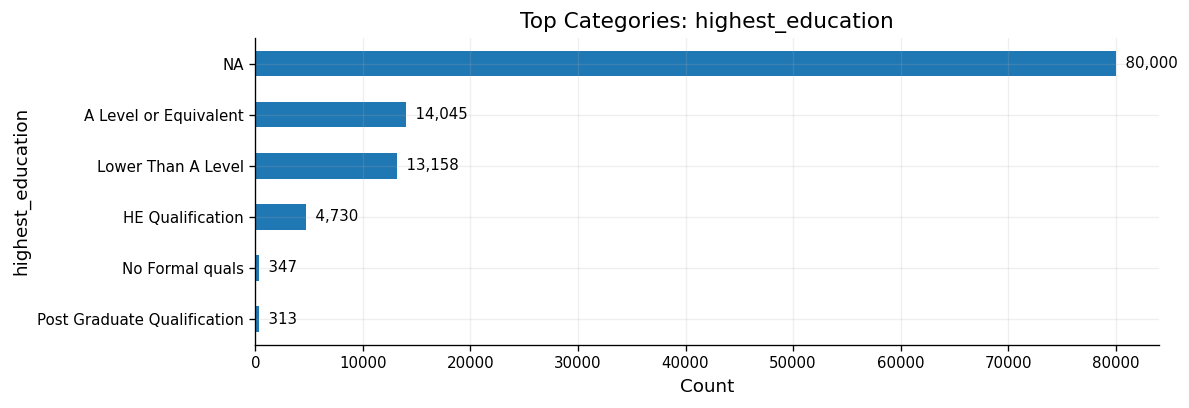


imd_band top levels:
imd_band
NA         81111
20-30%      3654
30-40%      3539
10-20       3516
0-10%       3311
40-50%      3256
50-60%      3124
60-70%      2905
70-80%      2879
80-90%      2762
90-100%     2536
Name: count, dtype: Int64


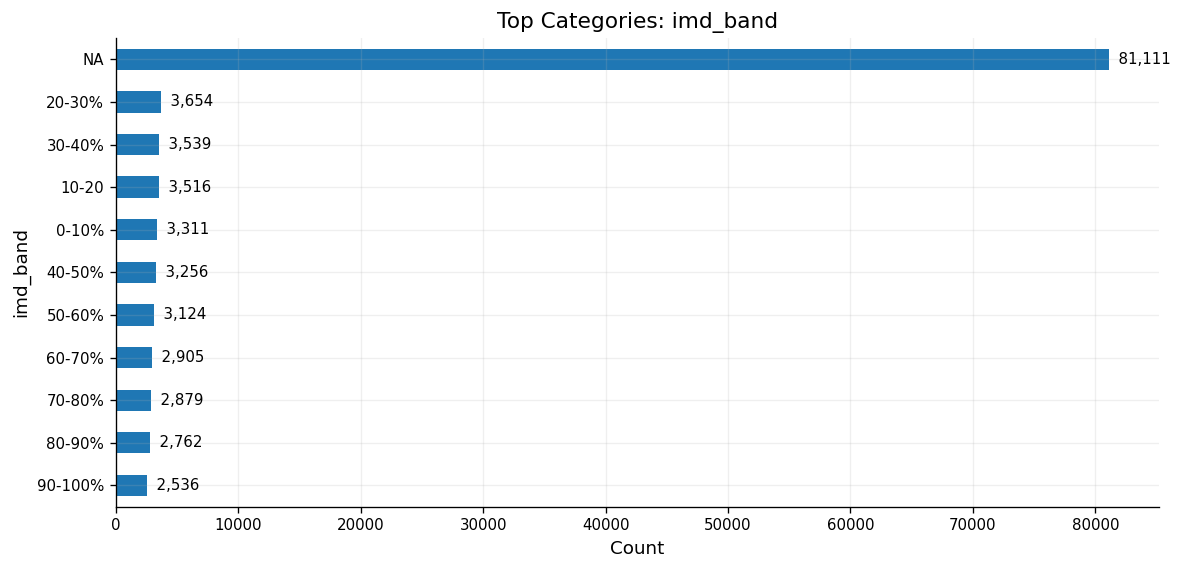


region top levels:
region
NA                      80000
Scotland                 3446
East Anglian Region      3340
London Region            3216
South Region             3092
North Western Region     2906
West Midlands Region     2582
South West Region        2436
East Midlands Region     2365
South East Region        2111
Wales                    2086
Yorkshire Region         2006
Name: count, dtype: Int64


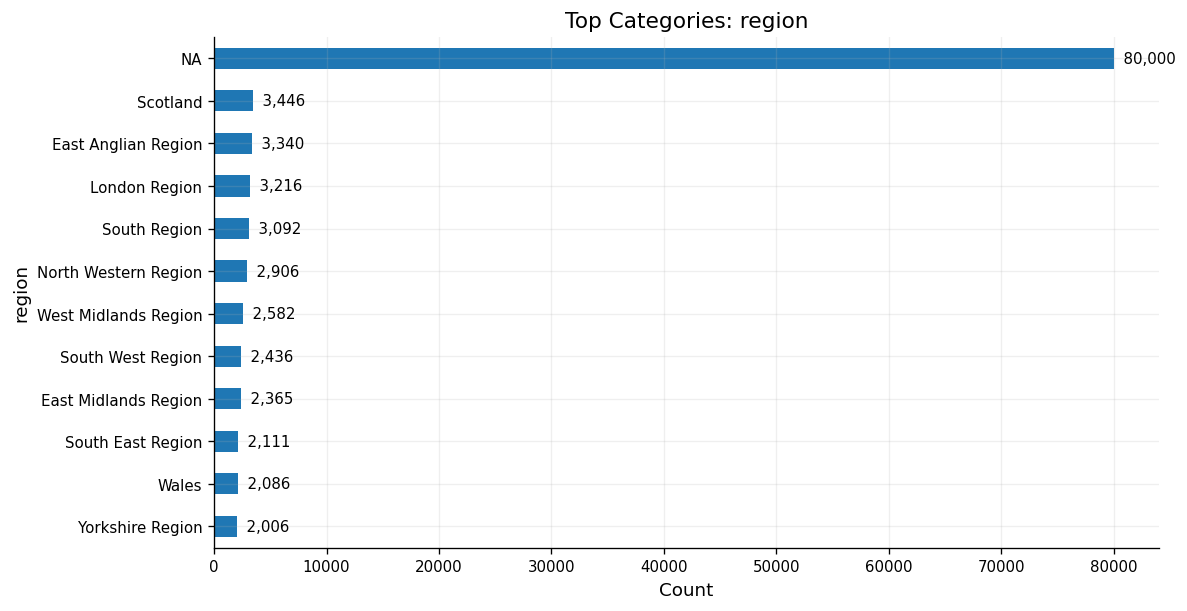

In [ ]:
# EDA BLOCK 7/10 — UNIVARIATE CATEGORICAL (TOP LEVELS, CLEAN HORIZONTAL)
print("\n" + "="*70)
print("EDA 7/10 — UNIVARIATE CATEGORICAL")
print("="*70)

cat_pref = ["dataset_source","gender_std","highest_education","imd_band","region"]
cat_show = [c for c in cat_pref if c in df.columns]
if len(cat_show) < 5:
    cat_show += [c for c in cat_cols if c not in cat_show][: (5-len(cat_show))]
cat_show = cat_show[:5]

print("Categorical columns shown:", cat_show)

for c in cat_show:
    print(f"\n{c} top levels:")
    vc = df[c].astype("string").fillna("NA").value_counts(dropna=False).head(12)
    print(vc)
    barh_top_counts(df[c], top=12, title=f"Top Categories: {c}", xlabel="Count")



EDA 8/10 — NUMERIC vs TARGET (COMBINED PLOT)
Numeric vs target columns: ['age_years', 'study_load', 'prior_perf', 'attendance_metric', 'weighted_score', 'mean_score', 'n_assess']


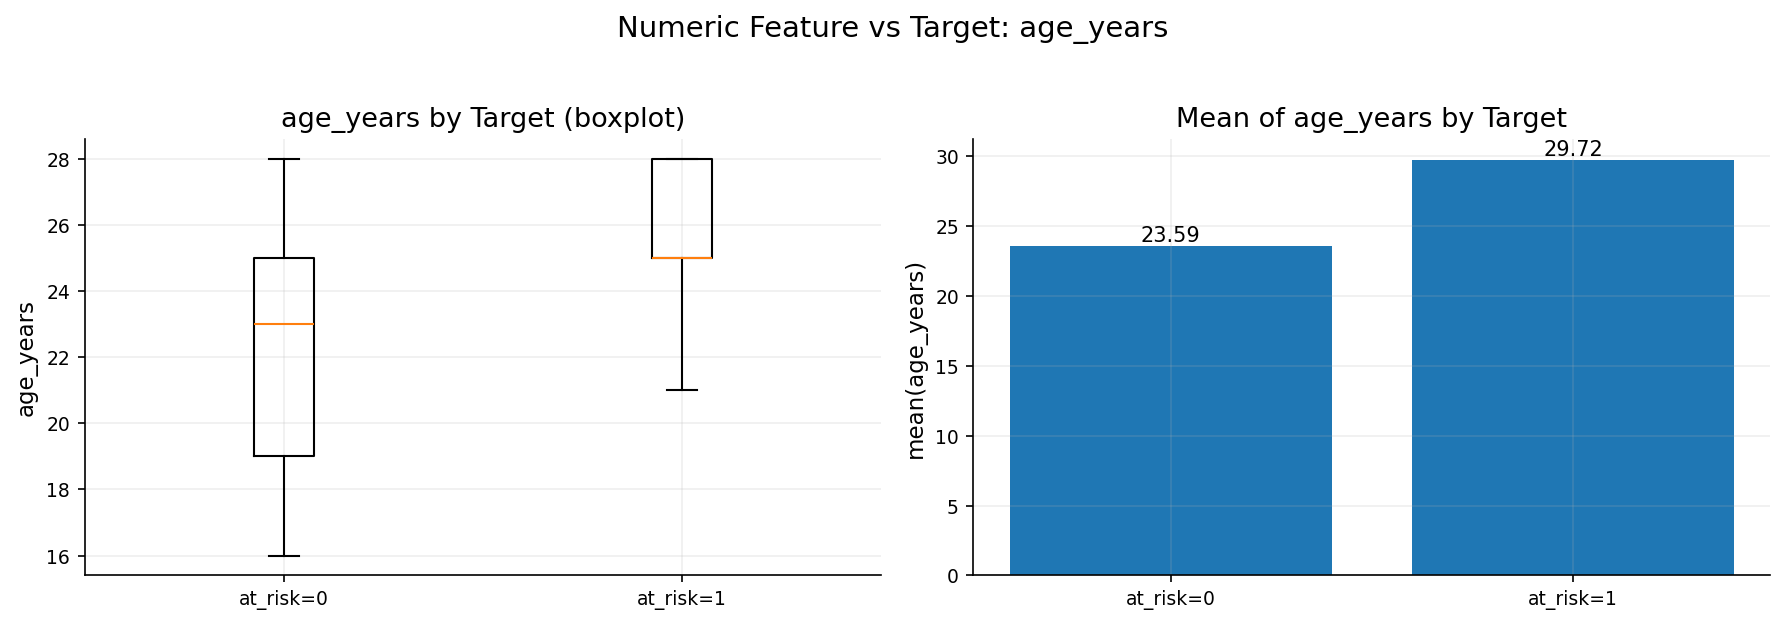

age_years: mean0=23.591, mean1=29.724, median0=23.000, median1=25.000


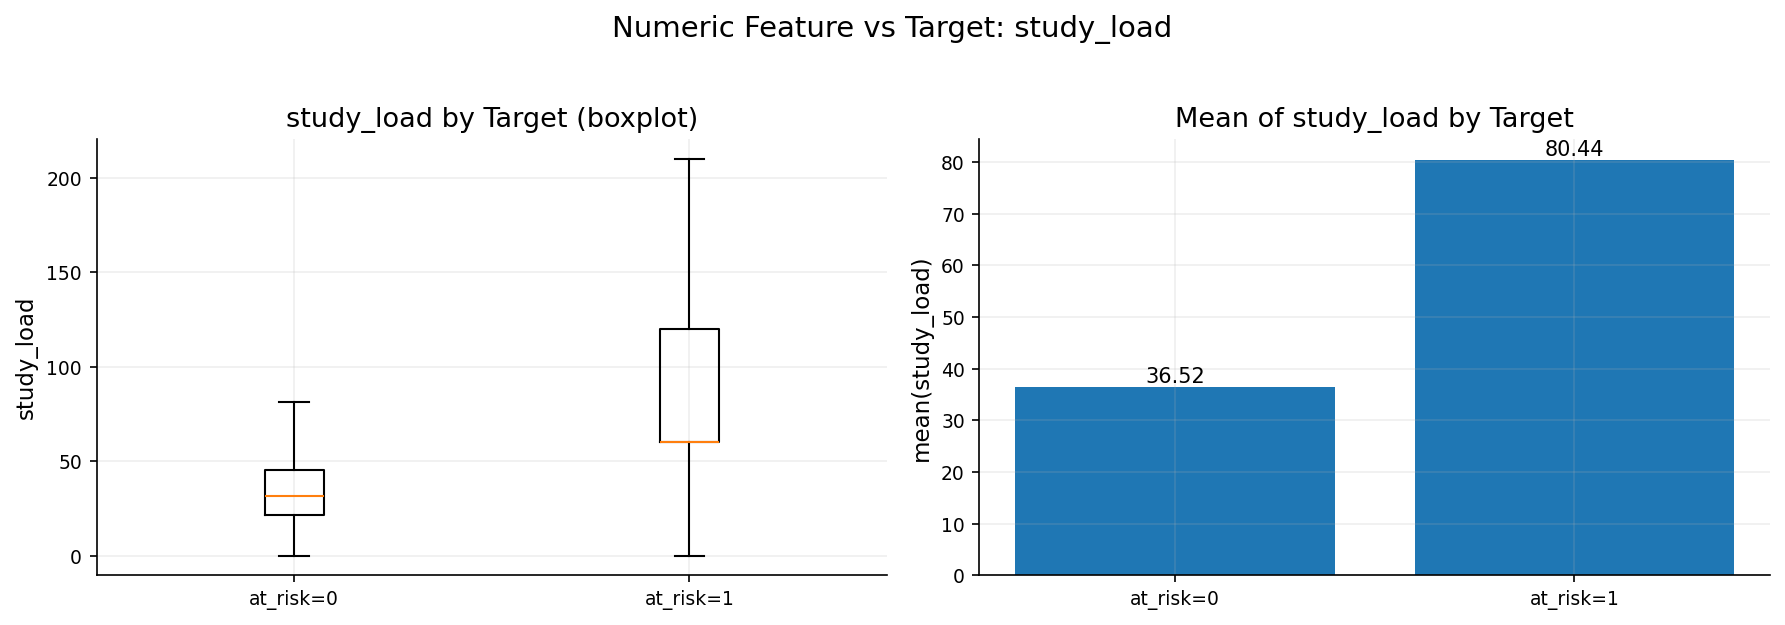

study_load: mean0=36.521, mean1=80.438, median0=31.500, median1=60.000


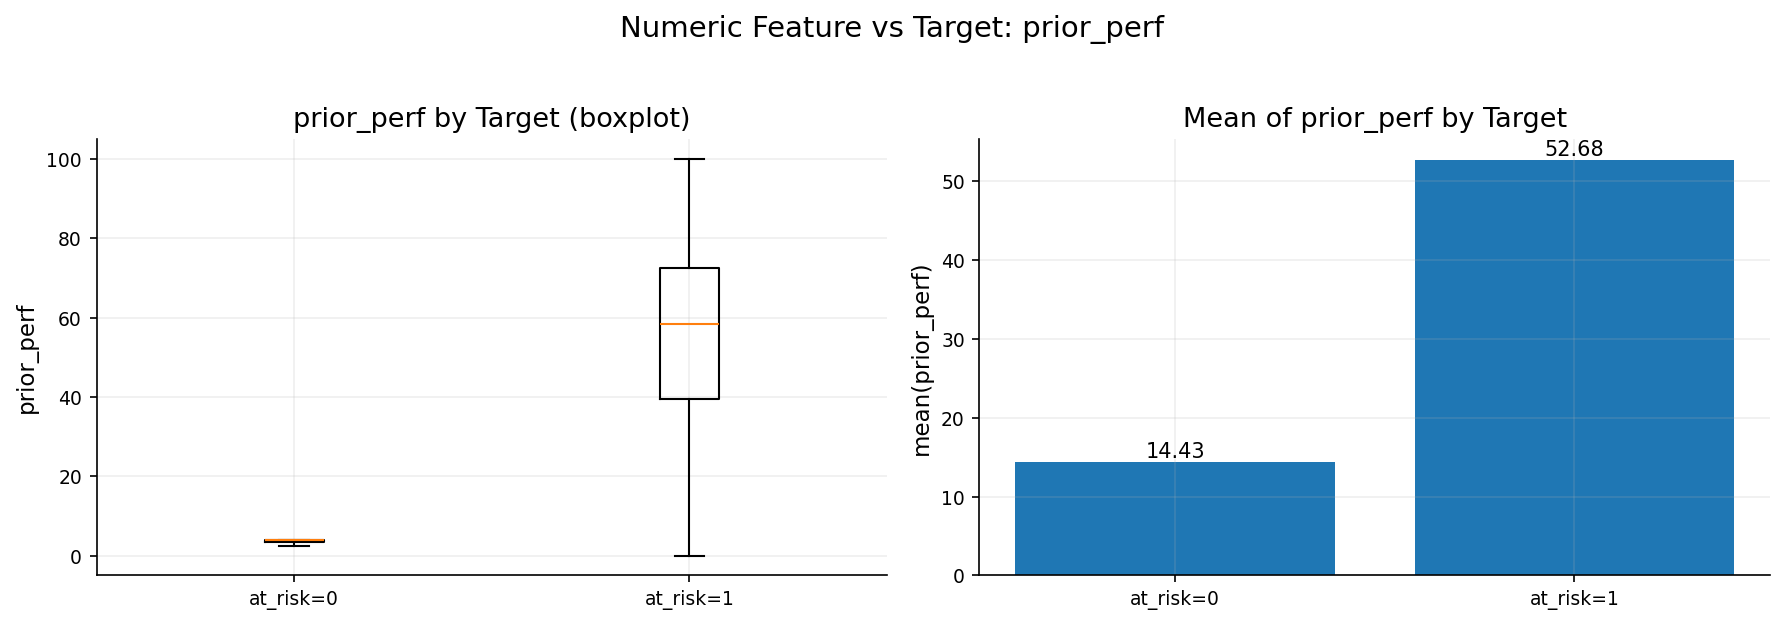

prior_perf: mean0=14.427, mean1=52.681, median0=3.980, median1=58.398


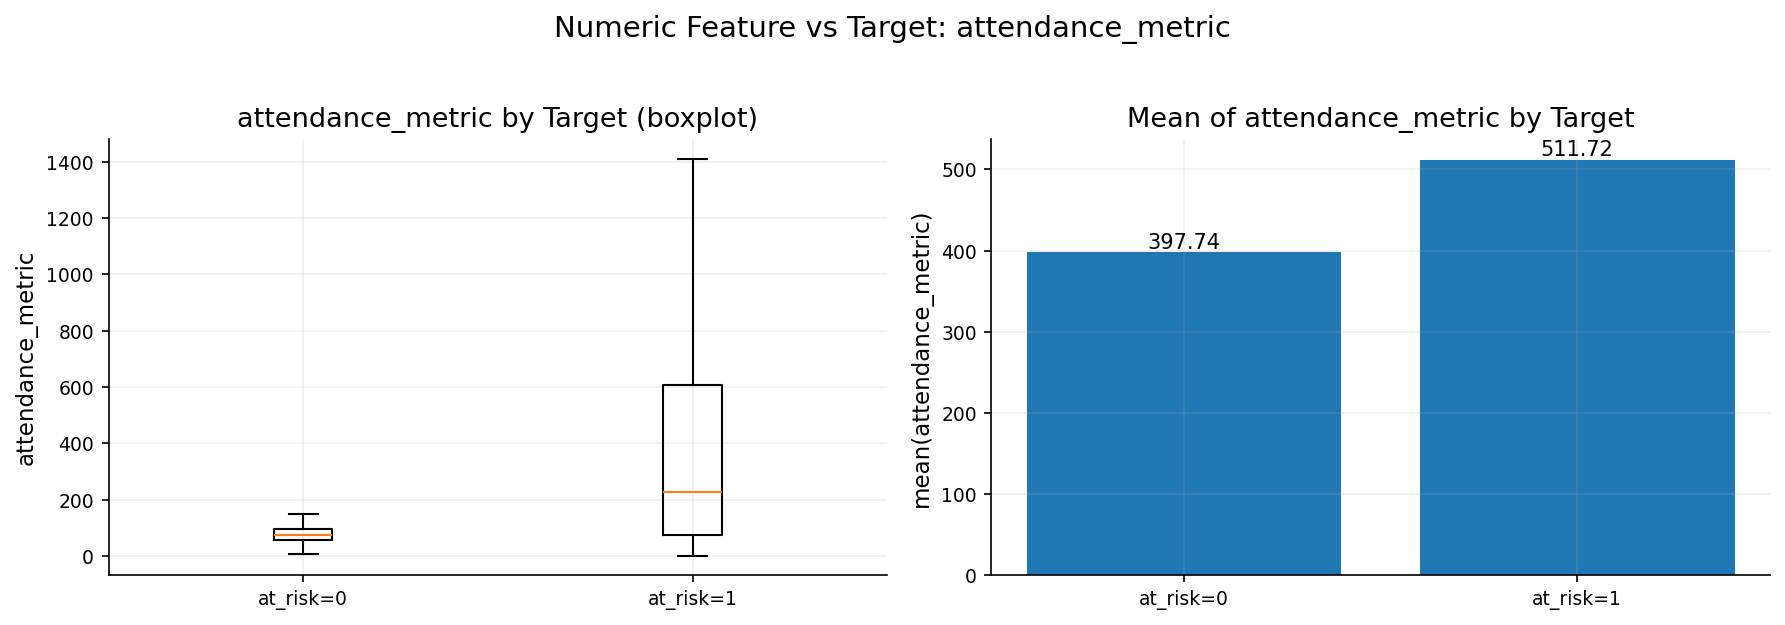

attendance_metric: mean0=397.737, mean1=511.720, median0=75.800, median1=226.000


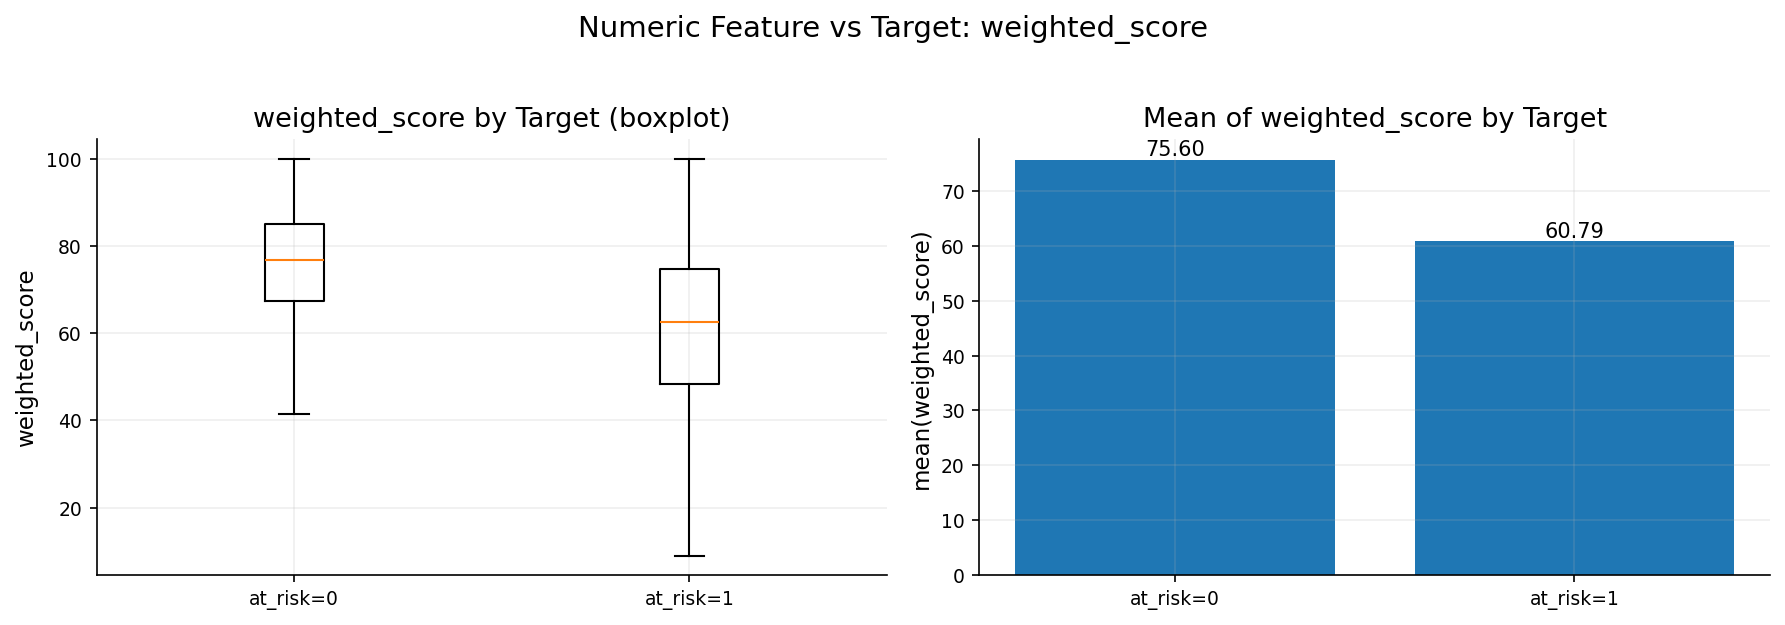

weighted_score: mean0=75.600, mean1=60.787, median0=76.850, median1=62.637


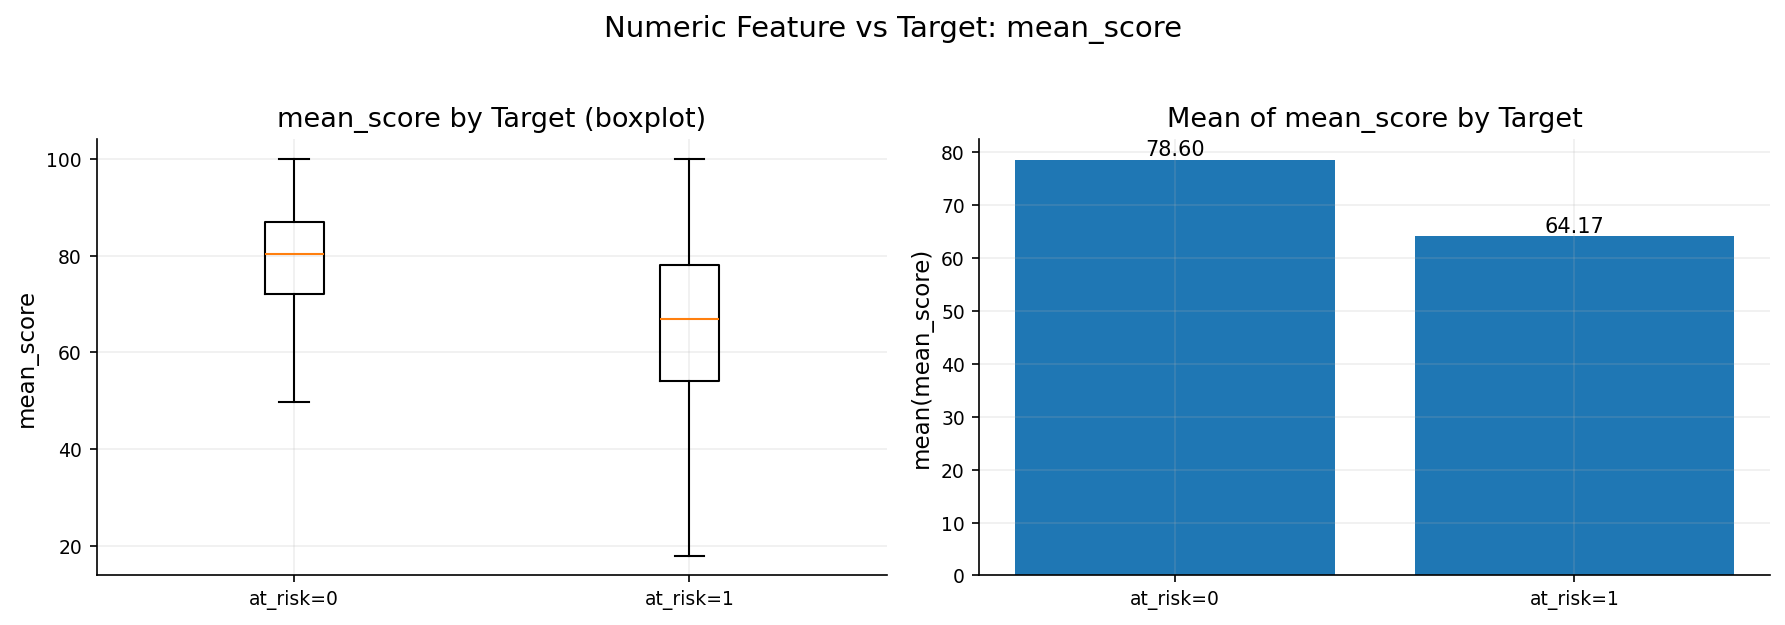

mean_score: mean0=78.600, mean1=64.175, median0=80.273, median1=66.845


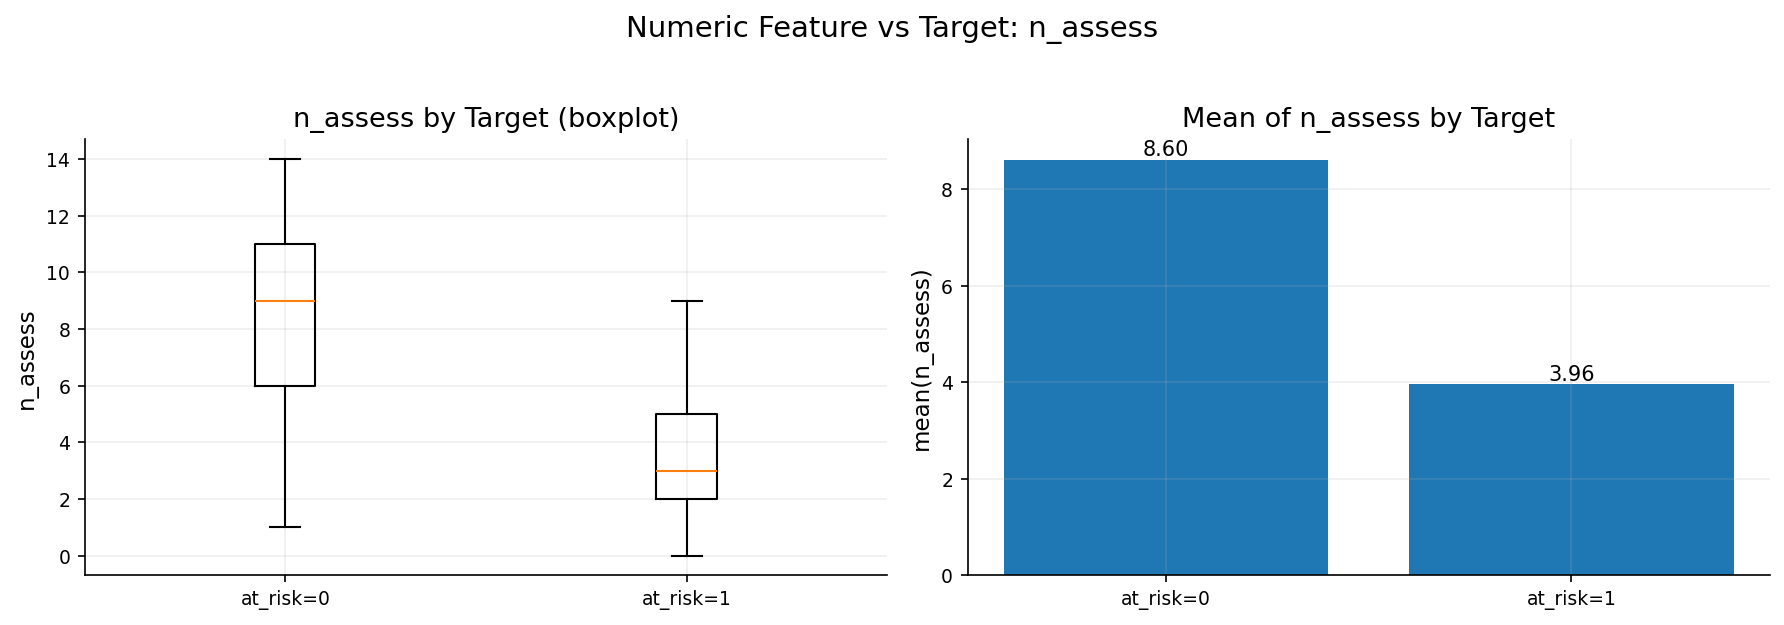

n_assess: mean0=8.602, mean1=3.960, median0=9.000, median1=3.000


In [ ]:
# REPLACE EDA BLOCK 8/10 — NUMERIC vs TARGET
print("\n" + "="*70)
print("EDA 8/10 — NUMERIC vs TARGET (COMBINED PLOT)")
print("="*70)

num_target_cols = [c for c in preferred if c in df.columns and is_numeric_dtype(df[c])]
num_target_cols = num_target_cols[:7] if len(num_target_cols) else num_cols[:6]
print("Numeric vs target columns:", num_target_cols)

plt.rcParams.update({"figure.dpi": 150})

for c in num_target_cols:
    s = pd.to_numeric(df[c], errors="coerce")
    x0 = s[df[target_col] == 0].dropna()
    x1 = s[df[target_col] == 1].dropna()

    if len(x0) == 0 or len(x1) == 0:
        print(f"{c}: skipped (one class empty)")
        continue

    means = [x0.mean(), x1.mean()]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # left: boxplot
    axes[0].boxplot([x0.values, x1.values], tick_labels=["at_risk=0", "at_risk=1"], showfliers=False)
    axes[0].set_title(f"{c} by Target (boxplot)")
    axes[0].set_ylabel(c)

    # right: mean bar
    axes[1].bar(["at_risk=0", "at_risk=1"], means)
    axes[1].set_title(f"Mean of {c} by Target")
    axes[1].set_ylabel(f"mean({c})")
    for i, v in enumerate(means):
        axes[1].text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=10)

    fig.suptitle(f"Numeric Feature vs Target: {c}", y=1.03, fontsize=14)
    plt.tight_layout()
    plt.show()

    print(f"{c}: mean0={x0.mean():.3f}, mean1={x1.mean():.3f}, median0={x0.median():.3f}, median1={x1.median():.3f}")



EDA 9/10 — CATEGORICAL vs TARGET (CLEAR)
Categorical vs target columns: ['dataset_source', 'gender_std', 'highest_education', 'imd_band']

dataset_source — top category at-risk rates:
dataset_source
OULAD     0.527966
HABITS    0.019775
Name: at_risk, dtype: float64


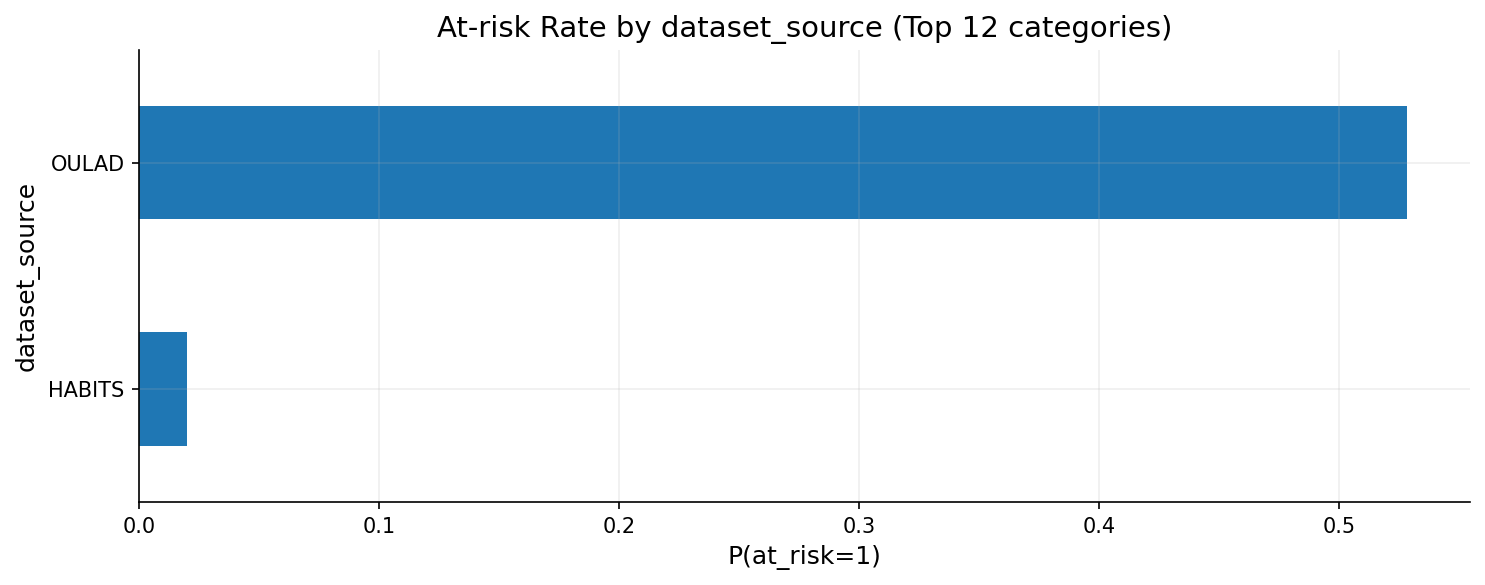


gender_std — top category at-risk rates:
gender_std
M        0.228277
F        0.195616
other    0.019250
Name: at_risk, dtype: float64


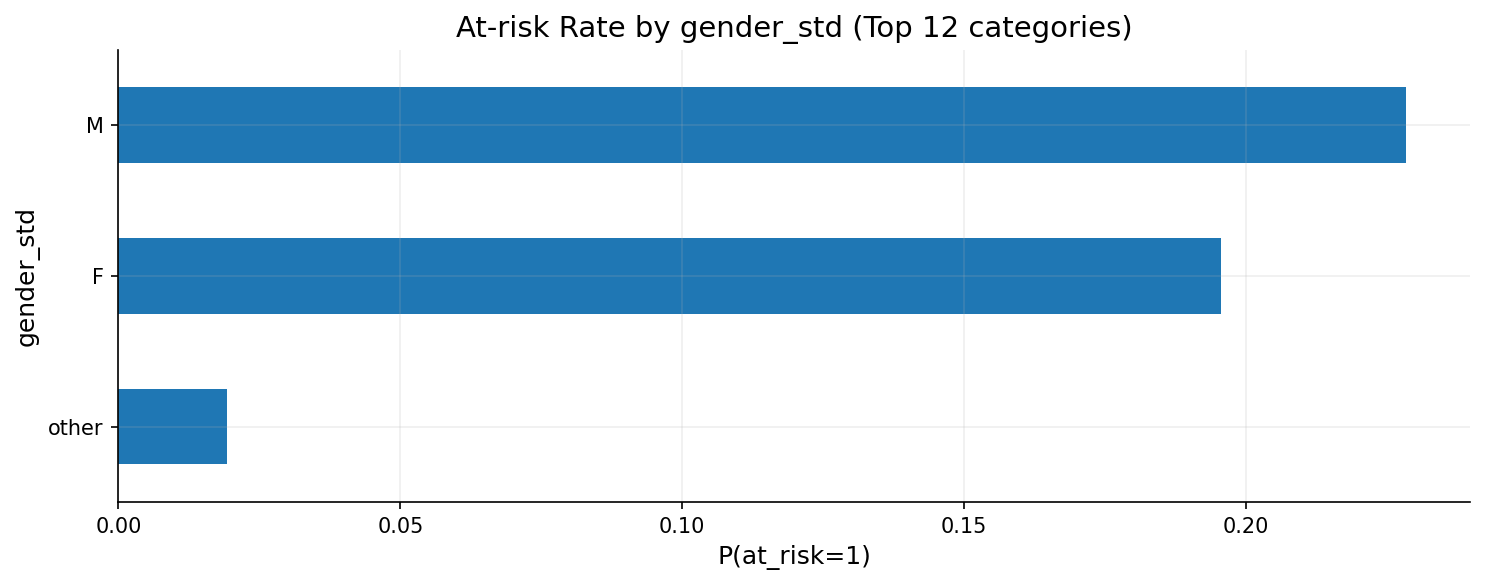


highest_education — top category at-risk rates:
highest_education
No Formal quals                0.703170
Lower Than A Level             0.611491
A Level or Equivalent          0.479672
HE Qualification               0.438266
Post Graduate Qualification    0.345048
NA                             0.019775
Name: at_risk, dtype: float64


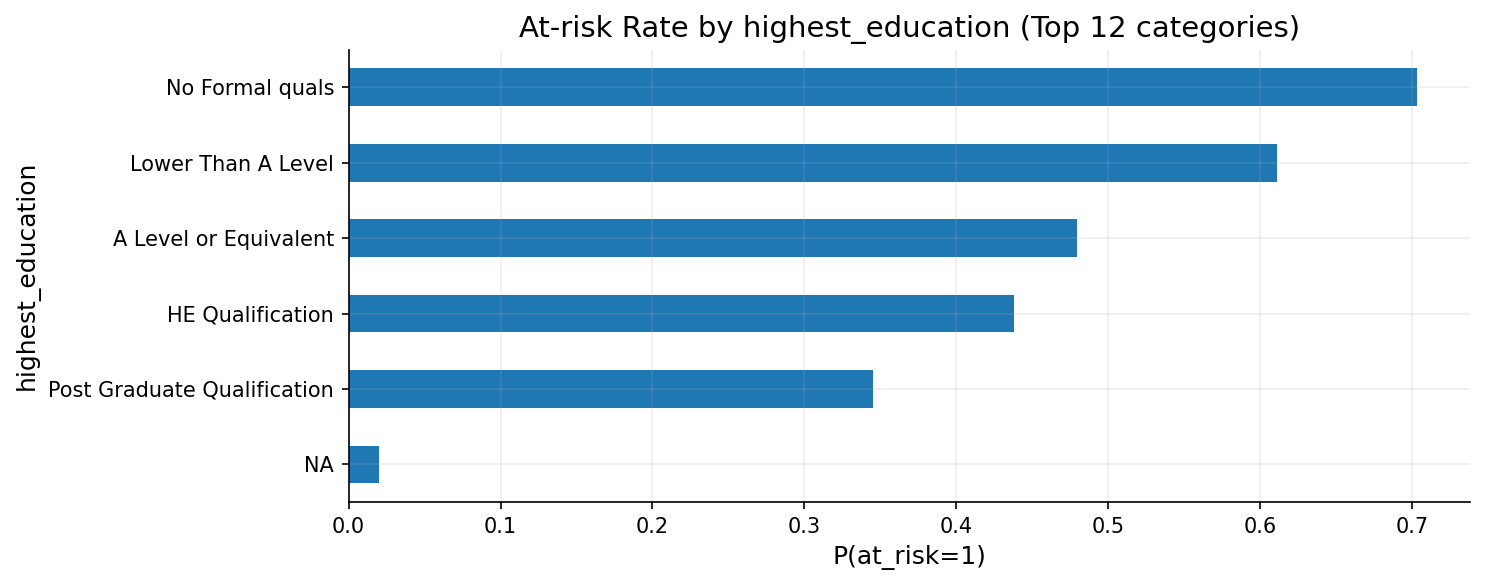


imd_band — top category at-risk rates:
imd_band
0-10%      0.648445
10-20      0.613766
20-30%     0.592501
40-50%     0.534091
30-40%     0.530941
50-60%     0.512164
70-80%     0.484891
60-70%     0.480895
80-90%     0.459450
90-100%    0.424685
Name: at_risk, dtype: float64


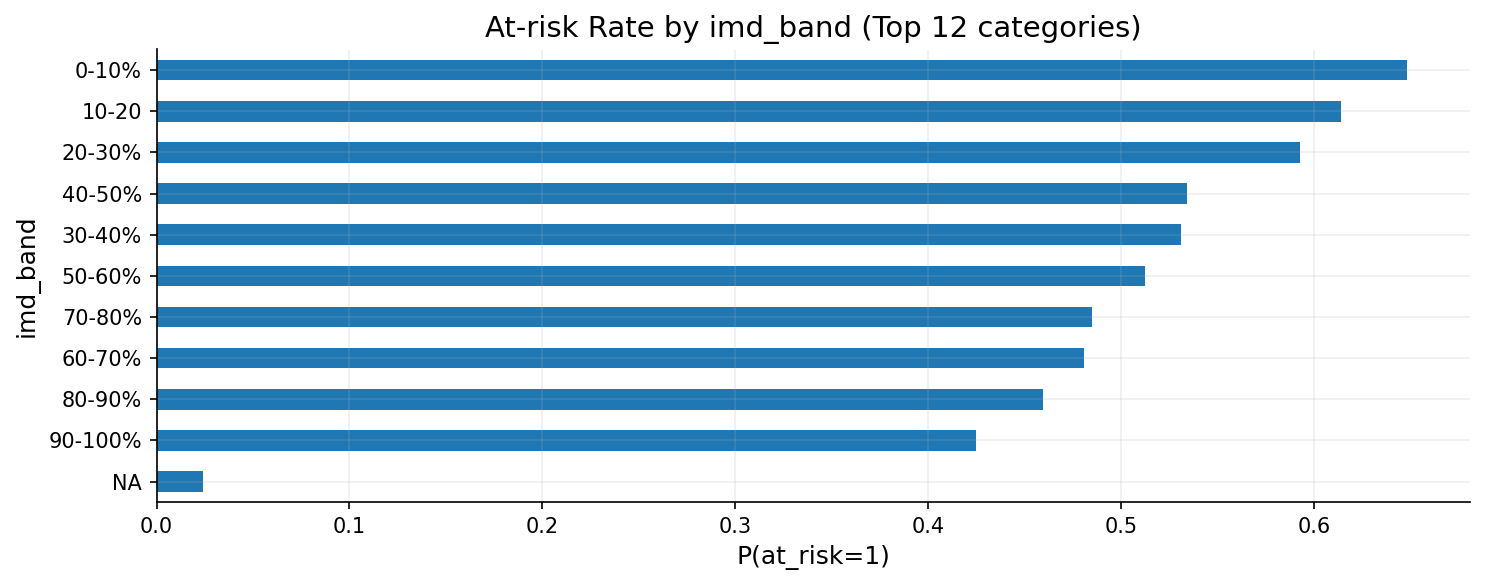

In [ ]:
# EDA BLOCK 9/10 — CATEGORICAL vs TARGET 
print("\n" + "="*70)
print("EDA 9/10 — CATEGORICAL vs TARGET")
print("="*70)

plt.rcParams.update({"figure.dpi": 150})

cat_target_cols = [c for c in ["dataset_source","gender_std","highest_education","imd_band"] if c in df.columns]
cat_target_cols = cat_target_cols[:4]
print("Categorical vs target columns:", cat_target_cols)

for c in cat_target_cols:
    tmp = df[[c, target_col]].copy()
    tmp[c] = tmp[c].astype("string").fillna("NA")

    # at-risk rate per category
    rate = tmp.groupby(c)[target_col].mean().sort_values(ascending=False)

    # keep top categories by frequency (so plot is readable)
    top = tmp[c].value_counts().head(12).index
    rate_top = rate.loc[rate.index.intersection(top)]

    print(f"\n{c} — top category at-risk rates:")
    print(rate_top.sort_values(ascending=False).head(10))

    fig, ax = plt.subplots(figsize=(10,4))
    rate_top.sort_values().plot(kind="barh", ax=ax)
    ax.set_title(f"At-risk Rate by {c} (Top 12 categories)")
    ax.set_xlabel("P(at_risk=1)")
    ax.set_ylabel(c)
    plt.tight_layout()
    plt.show()



CLEAN CORRELATION HEATMAP (FILTERED)
Selected columns: ['age_years', 'attendance_metric', 'attendance_percentage', 'entertainment_hours', 'exam_anxiety_score', 'exam_score', 'exercise_frequency', 'mental_health_rating', 'motivation_level', 'netflix_hours', 'parental_support_level', 'previous_gpa', 'prior_perf', 'screen_time', 'semester', 'sleep_hours', 'social_activity', 'social_media_hours', 'stress_level', 'study_hours_per_day', 'study_load', 'time_management_score']
Count: 22


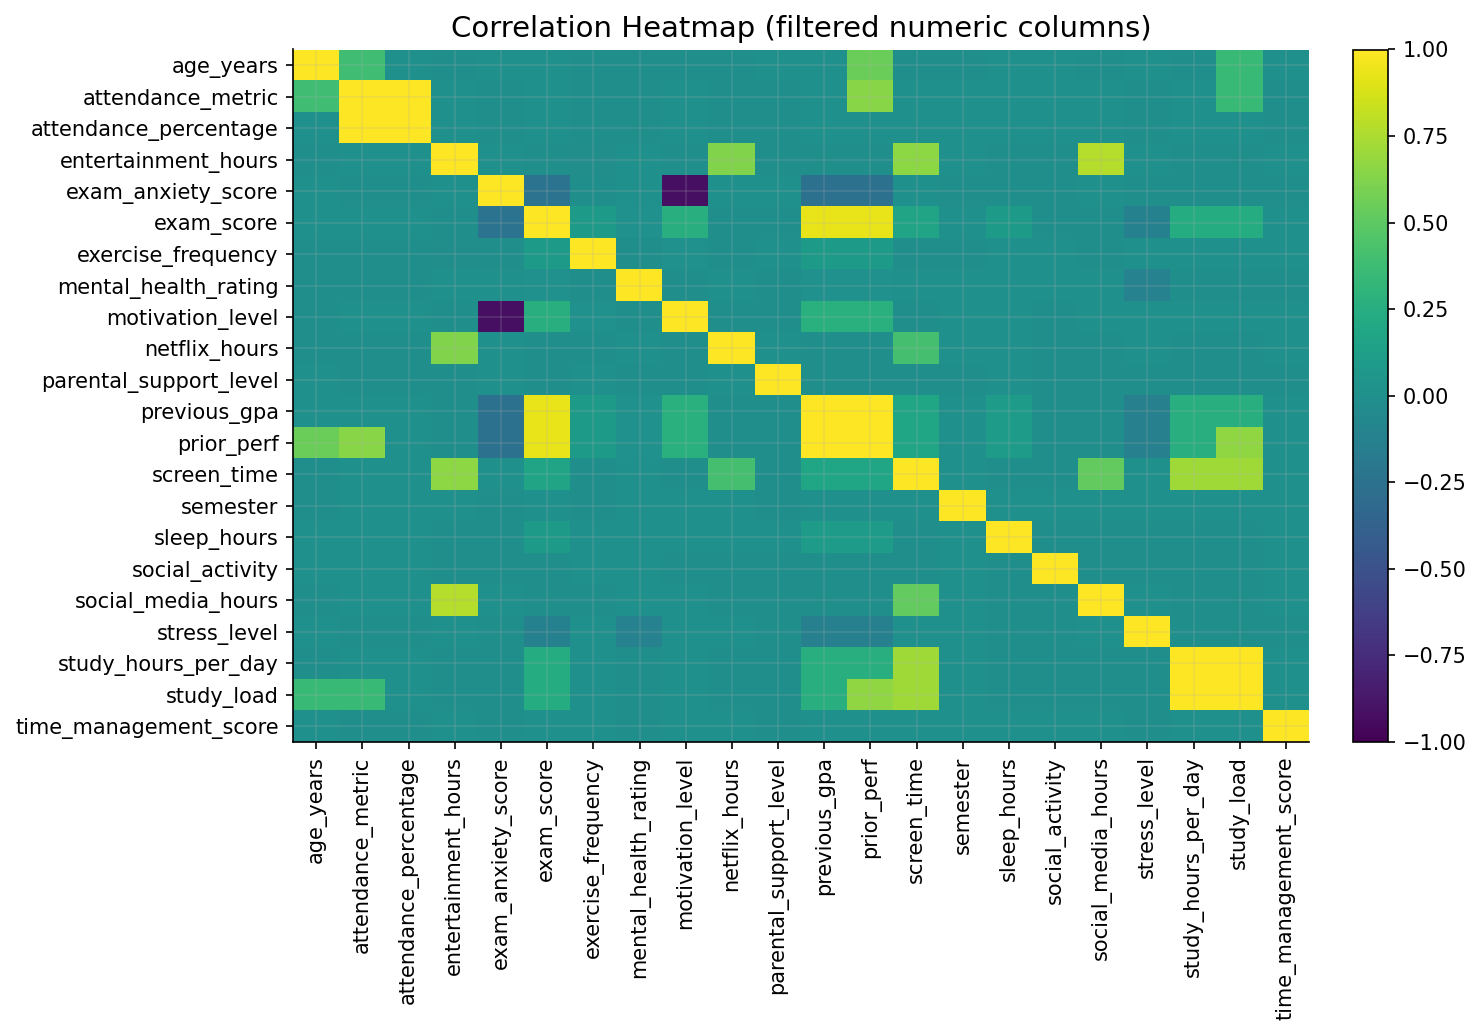

In [ ]:
# CLEAN HEATMAP — 
print("\n" + "="*70)
print("CLEAN CORRELATION HEATMAP (FILTERED)")
print("="*70)

min_non_null = int(0.6 * len(df))   # column must have at least 60% data
min_pair = 500                      # min overlapping rows for correlation

all_num = [c for c in df.columns if c != target_col and is_numeric_dtype(df[c])]
# optional: remove id-like columns if they exist
all_num = [c for c in all_num if c not in ["id_student"]]

good_cols = [c for c in all_num if df[c].notna().sum() >= min_non_null]
good_cols = good_cols[:25]  # limit for readability

print("Selected columns:", good_cols)
print("Count:", len(good_cols))

corr = df[good_cols].corr(numeric_only=True, min_periods=min_pair)

fig, ax = plt.subplots(figsize=(10,7), dpi=150)
cmap = plt.cm.viridis.copy()
cmap.set_bad(color="lightgray")  # NaNs show as light gray (not confusing white)

im = ax.imshow(corr.values, vmin=-1, vmax=1, aspect="auto", cmap=cmap)
ax.set_title("Correlation Heatmap (filtered numeric columns)")
ax.set_xticks(range(len(good_cols)))
ax.set_yticks(range(len(good_cols)))
ax.set_xticklabels(good_cols, rotation=90)
ax.set_yticklabels(good_cols)
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()



CHI-SQUARE + CRAMÉR'S V — SOURCE: HABITS | shape=(80000, 49)


,feature,n_levels_used,n_rows_used,p_value_sci,cramers_v,effect_size
0,parental_education_level,5,80000,5.67e-02,0.010713,Negligible
1,major,6,80000,1.46e-01,0.010125,Negligible
2,study_environment,5,80000,2.54e-01,0.008175,Negligible
3,diet_quality,3,80000,1.00e-01,0.007581,Negligible
4,gender_std,3,80000,3.20e-01,0.005340,Negligible
5,family_income_range,3,80000,5.46e-01,0.003891,Negligible
6,learning_style,4,80000,7.66e-01,0.003782,Negligible
7,internet_quality,3,80000,7.14e-01,0.002904,Negligible
8,extracurricular_participation,2,80000,5.64e-01,0.002128,Negligible
9,part_time_job,2,80000,5.89e-01,0.002001,Negligible


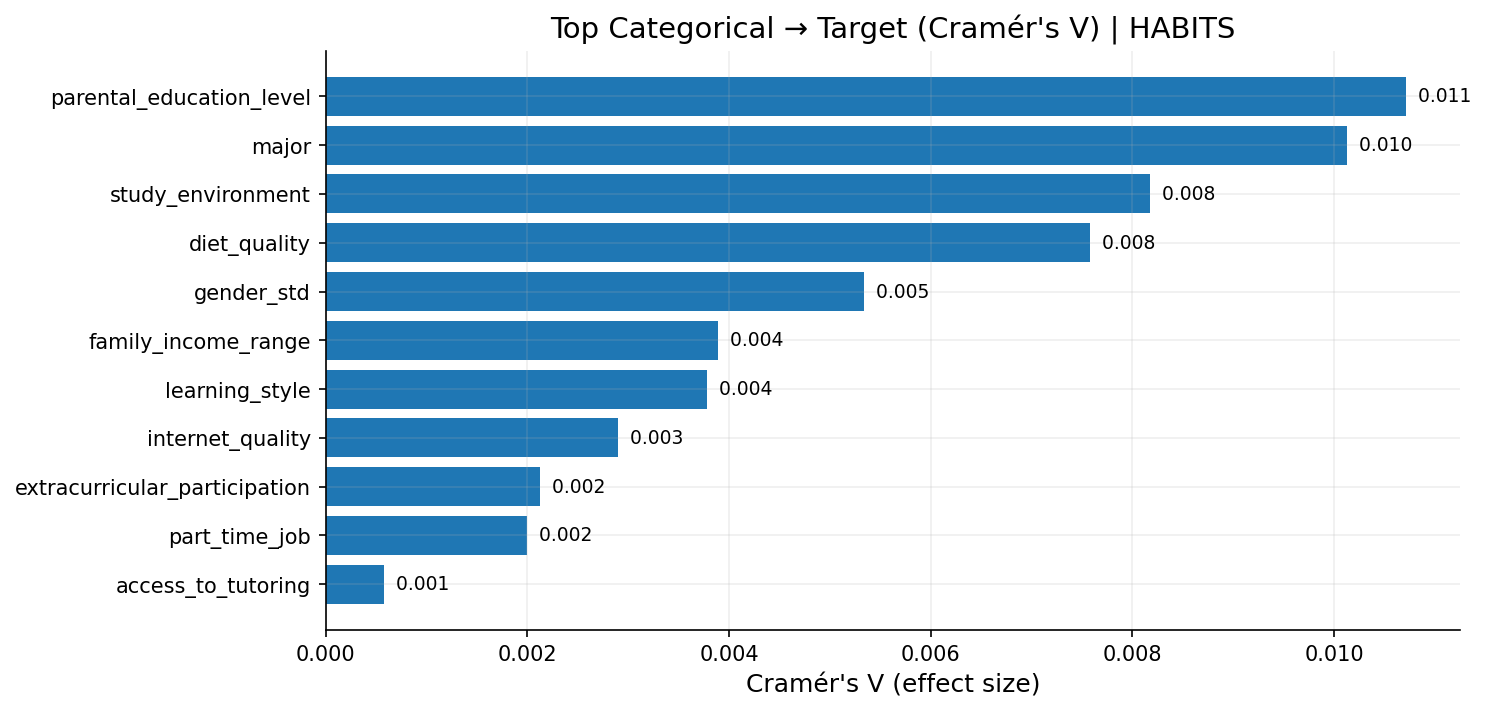


CHI-SQUARE + CRAMÉR'S V — SOURCE: OULAD | shape=(32593, 49)


,feature,n_levels_used,n_rows_used,p_value_sci,cramers_v,effect_size
0,highest_education,5,32593,3.00e-158,0.150399,Weak
1,code_module,7,32593,1.84e-139,0.142379,Weak
2,imd_band,10,31482,7.17e-116,0.133952,Weak
3,region,13,32593,4.71e-39,0.080980,Negligible
4,code_presentation,4,32593,1.47e-24,0.059155,Negligible
5,gender_std,2,32593,5.39e-05,0.022428,Negligible


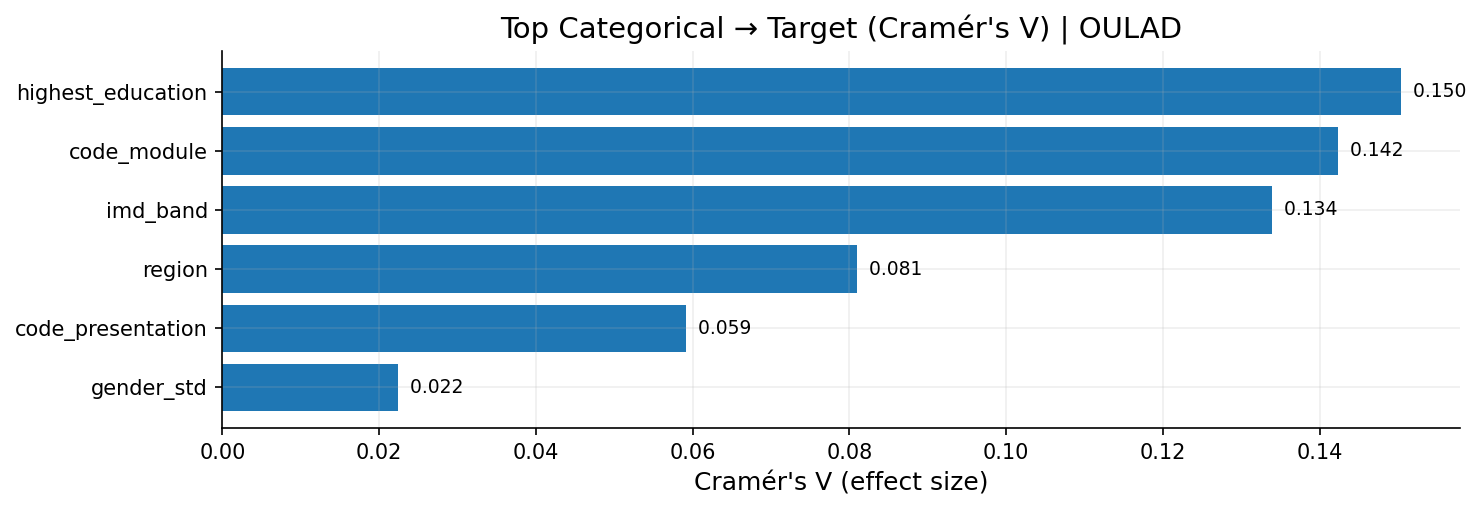

In [ ]:
from scipy.stats import chi2_contingency
try:
    from scipy.stats.contingency import association
    _HAS_ASSOC = True
except Exception:
    _HAS_ASSOC = False

from IPython.display import display

df = combined.copy()
TARGET = "at_risk"
SOURCE = "dataset_source"

def cramers_v_fallback(contingency: pd.DataFrame) -> float:
    chi2, p, dof, exp = chi2_contingency(contingency)
    n = contingency.to_numpy().sum()
    if n <= 1:
        return np.nan
    r, k = contingency.shape
    phi2 = chi2 / n
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    denom = min((kcorr-1), (rcorr-1))
    return float(np.sqrt(phi2corr / denom)) if denom > 0 else np.nan

def chisq_cramers_table(data: pd.DataFrame,
                        target: str,
                        cat_features=None,
                        max_levels=25,
                        min_total=50,
                        drop_na_target=True):
    if drop_na_target:
        data = data.dropna(subset=[target]).copy()

    if cat_features is None:
        cat_features = [c for c in data.columns if c != target and not pd.api.types.is_numeric_dtype(data[c])]

    rows = []
    for cat in cat_features:
        if cat not in data.columns:
            continue

        s = data[cat].astype("string")
        y = data[target]

        # keep only rows where the categorical value is not missing
        keep = s.notna()
        s = s[keep].fillna("NA")
        y = y[keep]

        if y.nunique(dropna=True) < 2:
            continue
        if len(s) < min_total:
            continue

        # limit huge cardinality (optional, makes results stable)
        if s.nunique(dropna=False) > max_levels:
            top = s.value_counts(dropna=False).head(max_levels - 1).index
            s = s.where(s.isin(top), other="Other")

        contingency = pd.crosstab(s, y)
        if contingency.shape[0] < 2 or contingency.shape[1] < 2:
            continue

        chi2, p_val, dof, expected = chi2_contingency(contingency)

        if _HAS_ASSOC:
            cramers = float(association(contingency, method="cramer"))
        else:
            cramers = cramers_v_fallback(contingency)

        # effect size interpretation (common rule of thumb)
        if np.isnan(cramers):
            effect = "NA"
        elif cramers >= 0.50:
            effect = "Strong"
        elif cramers >= 0.30:
            effect = "Moderate"
        elif cramers >= 0.10:
            effect = "Weak"
        else:
            effect = "Negligible"

        rows.append({
            "feature": cat,
            "n_levels_used": int(contingency.shape[0]),
            "n_rows_used": int(len(s)),
            "chi_sq": float(chi2),
            "p_value": float(p_val),
            "p_value_sci": f"{p_val:.2e}",
            "cramers_v": float(cramers),
            "effect_size": effect,
        })

    out = pd.DataFrame(rows)
    if len(out) == 0:
        return out

    out = out.sort_values(["cramers_v", "p_value"], ascending=[False, True]).reset_index(drop=True)
    return out

def plot_top_cramers(summary_df: pd.DataFrame, title: str, top=12):
    if summary_df is None or len(summary_df) == 0:
        print("No results to plot:", title)
        return
    top_df = summary_df.head(top).iloc[::-1]
    fig, ax = plt.subplots(figsize=(10, max(3.5, 0.35*len(top_df)+1)))
    ax.barh(top_df["feature"], top_df["cramers_v"])
    ax.set_title(title)
    ax.set_xlabel("Cramér's V (effect size)")
    for i, v in enumerate(top_df["cramers_v"].values):
        ax.text(v, i, f"  {v:.3f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()

# ---------------------------

assert SOURCE in df.columns, "dataset_source column missing in combined."

global_cat_candidates = [c for c in df.columns if c not in [TARGET] and not pd.api.types.is_numeric_dtype(df[c])]

# optional: remove dataset_source itself from testing (it will always be significant)
global_cat_candidates = [c for c in global_cat_candidates if c != SOURCE]

for src in sorted(df[SOURCE].astype("string").unique()):
    sub = df[df[SOURCE].astype("string") == src].copy()

    # only test categoricals that actually have values in this subset
    cat_features = []
    for c in global_cat_candidates:
        if c in sub.columns:
            miss_rate = sub[c].isna().mean()
            if miss_rate < 0.95:   # skip columns that are basically all missing for this source
                cat_features.append(c)

    print("\n" + "="*85)
    print(f"CHI-SQUARE + CRAMÉR'S V — SOURCE: {src} | shape={sub.shape}")
    print("="*85)

    res = chisq_cramers_table(
        sub,
        target=TARGET,
        cat_features=cat_features,
        max_levels=25,
        min_total=50
    )

    if len(res) == 0:
        print("No valid categorical features for chi-square in this source.")
        continue

    display(res[["feature","n_levels_used","n_rows_used","p_value_sci","cramers_v","effect_size"]].head(25))
    plot_top_cramers(res, title=f"Top Categorical → Target (Cramér's V) | {src}", top=12)



Data Preprocessing

In [ ]:
# BLOCK 8 — TRAIN/TEST SPLIT  + DROP ID and dataset_source COLUMNS FROM FEATURES
from sklearn.model_selection import train_test_split

target_col = "at_risk"
id_cols = ["code_module","code_presentation","id_student"]

X = combined.drop(columns=[target_col, "dataset_source"], errors="ignore")
y = combined[target_col].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("SPLIT:")
print("  X_train:", X_train.shape, "| y_train:", y_train.shape, dict(zip(*np.unique(y_train, return_counts=True))))
print("  X_test :", X_test.shape,  "| y_test :", y_test.shape,  dict(zip(*np.unique(y_test, return_counts=True))))

X_train = X_train.drop(columns=[c for c in id_cols if c in X_train.columns])
X_test  = X_test.drop(columns=[c for c in id_cols if c in X_test.columns])

print("\nAFTER DROPPING IDS:")
print("  X_train:", X_train.shape)
print("  X_test :", X_test.shape)


SPLIT:
  X_train: (90074, 47) | y_train: (90074,) {np.int64(0): np.int64(75042), np.int64(1): np.int64(15032)}
  X_test : (22519, 47) | y_test : (22519,) {np.int64(0): np.int64(18761), np.int64(1): np.int64(3758)}

AFTER DROPPING IDS:
  X_train: (90074, 44)
  X_test : (22519, 44)


In [ ]:
# BLOCK 9 — PREPROCESS (IMPUTE + ONEHOT + SCALE)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

cat_cols = [c for c in X_train.columns if str(X_train[c].dtype) in ("object","category","bool")]
num_cols = [c for c in X_train.columns if c not in cat_cols]

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler(with_mean=False)),
])

try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=True)

cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", ohe),
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

X_train_pp = preprocess.fit_transform(X_train)
X_test_pp = preprocess.transform(X_test)

print("PREPROCESS DONE:")
print("  num_cols:", len(num_cols), "| cat_cols:", len(cat_cols))
print("  X_train_pp:", X_train_pp.shape)
print("  X_test_pp :", X_test_pp.shape)


PREPROCESS DONE:
  num_cols: 30 | cat_cols: 14
  X_train_pp: (90074, 96)
  X_test_pp : (22519, 96)


In [ ]:
# BLOCK 10 — BALANCING (RANDOM OVERSAMPLING)  
y_arr = np.asarray(y_train)

idx0 = np.where(y_arr == 0)[0]
idx1 = np.where(y_arr == 1)[0]

print("BALANCING INPUT:")
print("  class 0:", len(idx0))
print("  class 1:", len(idx1))

if len(idx0) == 0 or len(idx1) == 0:
    X_train_bal, y_train_bal = X_train_pp, y_arr
    method = "NO_BALANCE_SINGLE_CLASS"
else:
    if len(idx0) >= len(idx1):
        maj, mino = idx0, idx1
        min_label = 1
    else:
        maj, mino = idx1, idx0
        min_label = 0

    n_to_add = len(maj) - len(mino)
    add_idx = np.random.choice(mino, size=n_to_add, replace=True)

    all_idx = np.concatenate([np.arange(len(y_arr)), add_idx])
    X_train_bal = X_train_pp[all_idx]
    y_train_bal = y_arr[all_idx]
    method = f"RANDOM_OVERSAMPLE (minority={min_label})"

print("BALANCING DONE:", method)
print("  Before:", dict(zip(*np.unique(y_arr, return_counts=True))))
print("  After :", dict(zip(*np.unique(y_train_bal, return_counts=True))))
print("  X_train_bal:", X_train_bal.shape)
print("  y_train_bal:", y_train_bal.shape)


BALANCING INPUT:
  class 0: 75042
  class 1: 15032
BALANCING DONE: RANDOM_OVERSAMPLE (minority=1)
  Before: {np.int64(0): np.int64(75042), np.int64(1): np.int64(15032)}
  After : {np.int64(0): np.int64(75042), np.int64(1): np.int64(75042)}
  X_train_bal: (150084, 96)
  y_train_bal: (150084,)


In [ ]:
# BLOCK 11 — FINAL SUMMARY (READY FOR MODEL TRAINING)
print("\n" + "="*60)
print("PREPROCESSING COMPLETE — READY FOR MODEL TRAINING")
print("="*60)

print(f"\n📊 DATA SHAPES:")
print(f"   X_train_bal: {X_train_bal.shape}")
print(f"   y_train_bal: {y_train_bal.shape}")
print(f"   X_test:      {X_test_pp.shape}")
print(f"   y_test:      {y_test.shape}")

print(f"\n✓ Next: Train classification models")



PREPROCESSING COMPLETE — READY FOR MODEL TRAINING

📊 DATA SHAPES:
   X_train_bal: (150084, 96)
   y_train_bal: (150084,)
   X_test:      (22519, 96)
   y_test:      (22519,)

✓ Next: Train classification models


Model training

Random Forest

In [ ]:
# 15) Random Forest Classifier Training & Evaluation
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

rf_classifier = RandomForestClassifier(n_estimators=15, random_state=42, max_depth=30)
rf_classifier.fit(X_train_bal, y_train_bal)

y_pred = rf_classifier.predict(X_test_pp)
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print(f'Accuracy of Random Forest: {accuracy}')
print(f'Confusion Matrix:\n{confusion}')
print(f'Classification Report:\n{report}')

Accuracy of Random Forest: 0.9683822549846796
Confusion Matrix:
[[18355   406]
 [  306  3452]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9836    0.9784    0.9810     18761
           1     0.8948    0.9186    0.9065      3758

    accuracy                         0.9684     22519
   macro avg     0.9392    0.9485    0.9437     22519
weighted avg     0.9688    0.9684    0.9685     22519



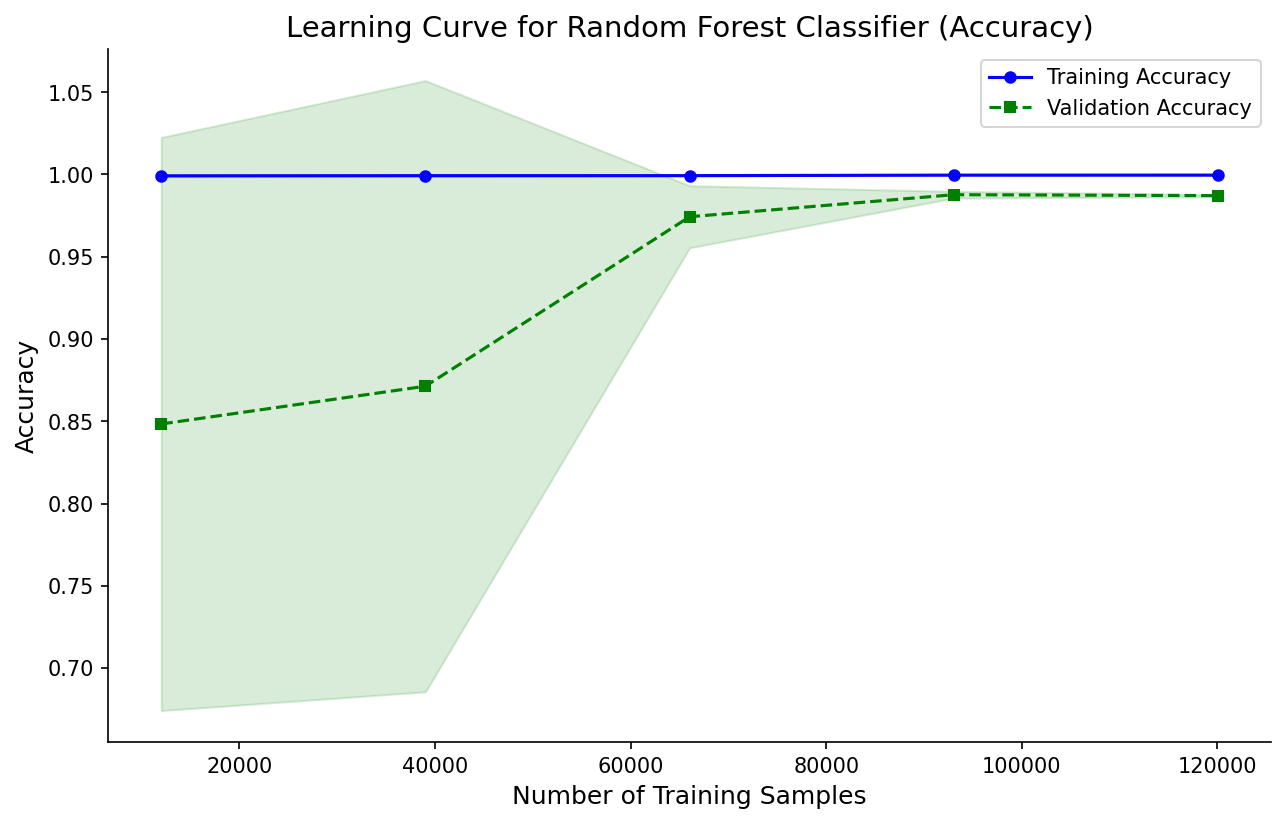

In [ ]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

rf_classifier = RandomForestClassifier(n_estimators=15, random_state=42, max_depth=30)

# Generate a learning curve based on log loss
train_sizes, train_scores, test_scores = learning_curve(
    rf_classifier,
    X_train_bal,
    y_train_bal,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Calculate mean and standard deviation for training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curve based on log loss
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='blue'
)

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation Accuracy')
plt.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.15,
    color='green'
)

plt.title('Learning Curve for Random Forest Classifier (Accuracy)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.grid()
plt.show()


In [ ]:
# 16) GridSearchCV for Random Forest Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

# Create a Random Forest classifier
rf_classifier = RandomForestClassifier()

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [20,40,100,200],
    'max_depth': [30, 40,50]
}

# Create GridSearchCV object
grid_search = GridSearchCV(
    estimator=rf_classifier,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the model to the training data
grid_search.fit(X_train_bal, y_train_bal)

# Print the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Get the best model
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_rf_model.predict(X_test_pp)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Best Hyperparameters: {'max_depth': 50, 'n_estimators': 20}
Accuracy: 0.9706026022469915
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98     18761
           1       0.91      0.91      0.91      3758

    accuracy                           0.97     22519
   macro avg       0.95      0.95      0.95     22519
weighted avg       0.97      0.97      0.97     22519



In [ ]:
# 17) Train Random Forest with Best Hyperparameters
rf_tuning = RandomForestClassifier(n_estimators=20, random_state=42, max_depth=50)
rf_tuning.fit(X_train_bal, y_train_bal)
y_pred = rf_tuning.predict(X_test_pp)

accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print(f'Accuracy of Random Forest: {accuracy}')
print(f'Confusion Matrix:\n{confusion}')
print(f'Classification Report:\n{report}')

Accuracy of Random Forest: 0.9698476841778054
Confusion Matrix:
[[18423   338]
 [  341  3417]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9818    0.9820    0.9819     18761
           1     0.9100    0.9093    0.9096      3758

    accuracy                         0.9698     22519
   macro avg     0.9459    0.9456    0.9458     22519
weighted avg     0.9698    0.9698    0.9698     22519



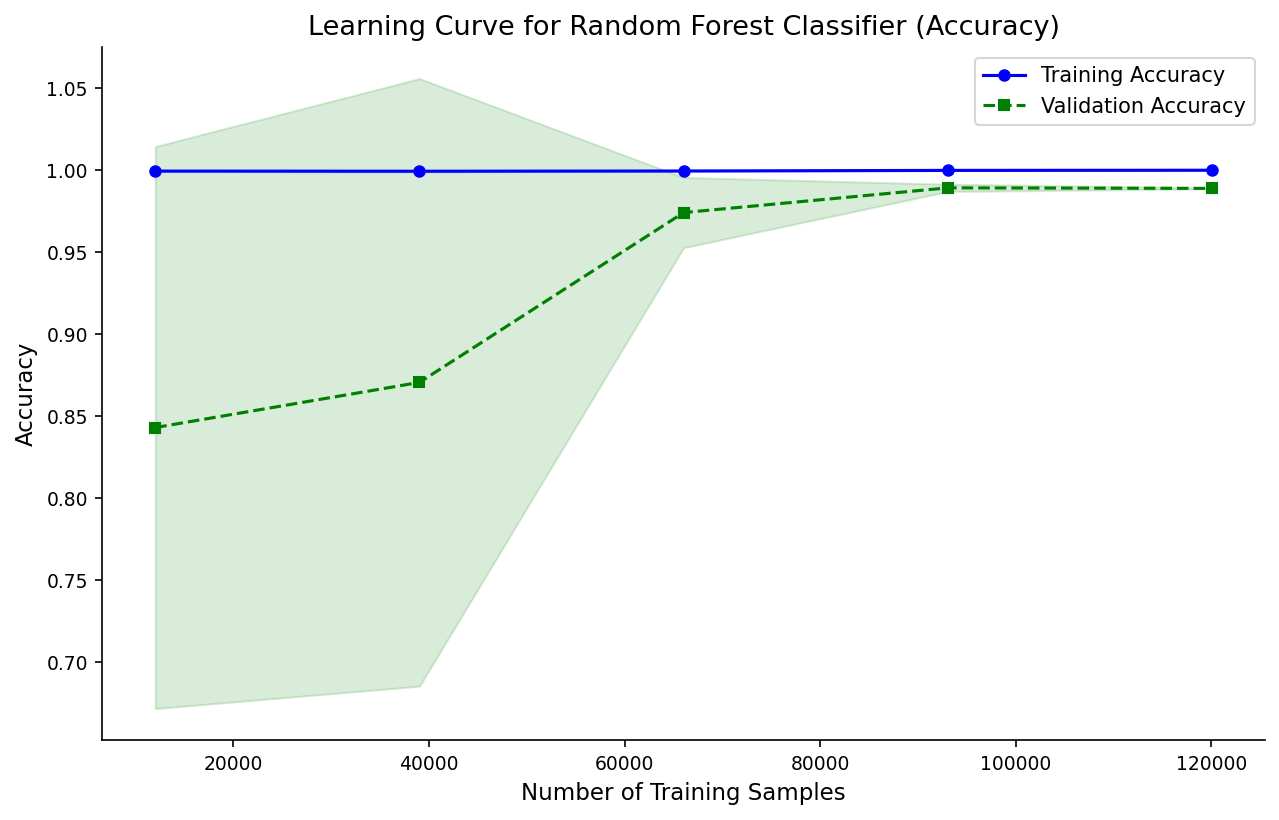

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np

rf_classifier = RandomForestClassifier(n_estimators=20, random_state=42, max_depth=50)

# Generate a learning curve based on log loss
train_sizes, train_scores, test_scores = learning_curve(
    rf_classifier,
    X_train_bal,
    y_train_bal,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Calculate mean and standard deviation for training set scores
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

# Calculate mean and standard deviation for test set scores
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

# Plot the learning curve based on log loss
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, color='blue', marker='o', markersize=5, label='Training Accuracy')
plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15,
    color='blue'
)

plt.plot(train_sizes, test_mean, color='green', linestyle='--', marker='s', markersize=5, label='Validation Accuracy')
plt.fill_between(
    train_sizes,
    test_mean - test_std,
    test_mean + test_std,
    alpha=0.15,
    color='green'
)

plt.title('Learning Curve for Random Forest Classifier (Accuracy)')
plt.xlabel('Number of Training Samples')
plt.ylabel('Accuracy')
plt.legend(loc='upper right')
plt.grid()
plt.show()


Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create a Decision Tree classifier
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier on the training data
decision_tree_classifier.fit(X_train_bal, y_train_bal)

# Make predictions on the testing data
y_pred = decision_tree_classifier.predict(X_test_pp)

# Calculate and print the accuracy and classification report of the classifier
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print("Accuracy of Decision Tree Classifier:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", report)


Accuracy of Decision Tree Classifier: 0.9633198632266087
Confusion Matrix:
 [[18333   428]
 [  398  3360]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9788    0.9772    0.9780     18761
           1     0.8870    0.8941    0.8905      3758

    accuracy                         0.9633     22519
   macro avg     0.9329    0.9356    0.9343     22519
weighted avg     0.9634    0.9633    0.9634     22519



In [ ]:
# LEARNING CURVE FUNCTION (reuse for base + tuned Decision Tree)
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X, y, title, scoring="accuracy"):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    test_mean  = np.mean(test_scores, axis=1)
    test_std   = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, marker='o', markersize=5, label='Training Accuracy')
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15)

    plt.plot(train_sizes, test_mean, linestyle='--', marker='s', markersize=5, label='Validation Accuracy')
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.15)

    plt.title(title)
    plt.xlabel('Number of Training Samples')
    plt.ylabel('Accuracy')
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()


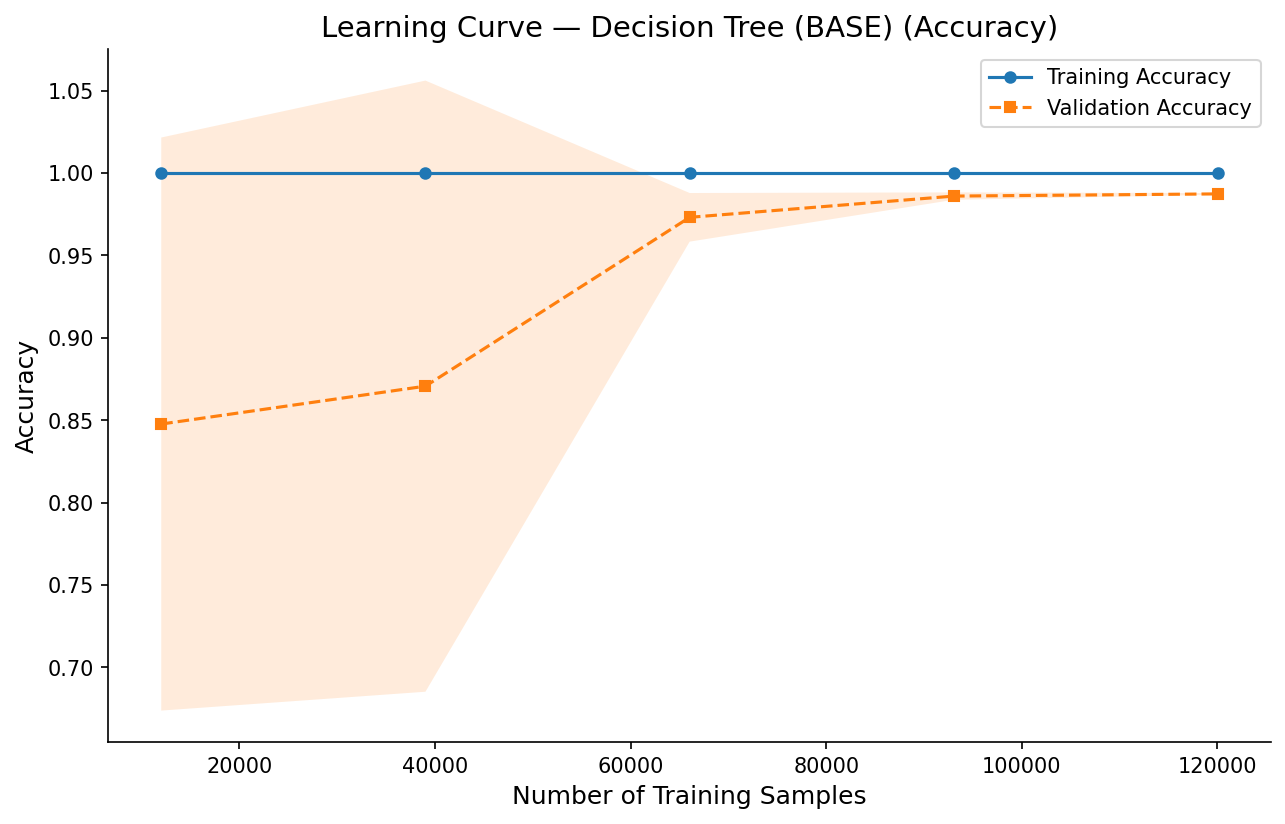

In [ ]:
# LEARNING CURVE — BASE DECISION TREE
from sklearn.tree import DecisionTreeClassifier

dt_base = DecisionTreeClassifier(random_state=42)

plot_learning_curve(
    dt_base,
    X_train_bal,
    y_train_bal,
    title="Learning Curve — Decision Tree (BASE) (Accuracy)",
    scoring="accuracy"
)


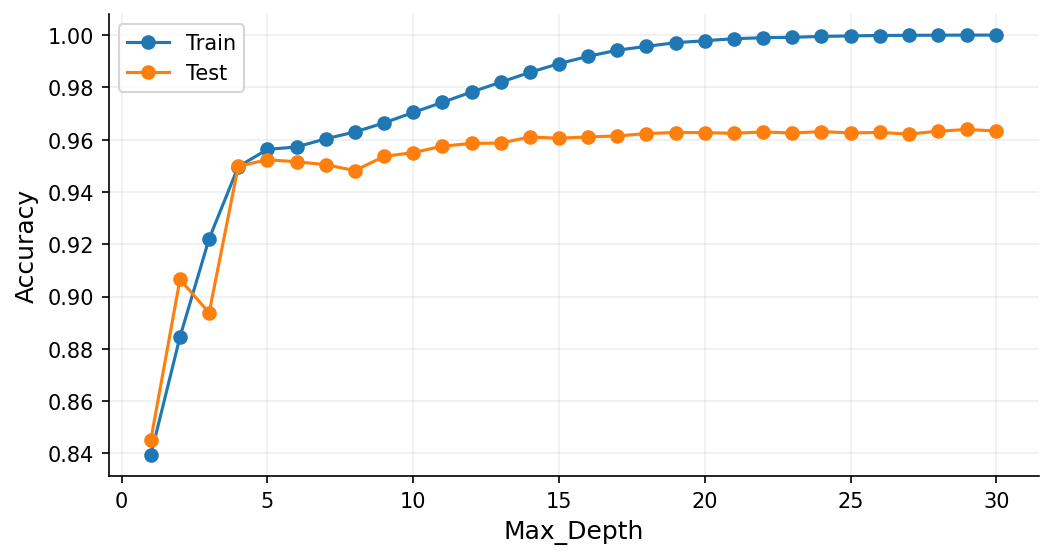

In [ ]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

train_score, test_score = list(), list()
values = [i for i in range(1, 31)]

for i in values:
    model = DecisionTreeClassifier(max_depth=i, random_state=42)
    model.fit(X_train_bal, y_train_bal)

    train_yhat = model.predict(X_train_bal)
    train_accuracy = accuracy_score(y_train_bal, train_yhat)
    train_score.append(train_accuracy)

    test_yhat = model.predict(X_test_pp)
    test_accuracy = accuracy_score(y_test, test_yhat)
    test_score.append(test_accuracy)

plt.plot(values, train_score, '-o', label='Train')
plt.plot(values, test_score, '-o', label='Test')
plt.xlabel('Max_Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Create a Decision Tree classifier
decision_tree_classifier = DecisionTreeClassifier(random_state=42)

# Define hyperparameters and their possible values for tuning base on previous plot
param_grid = {
    'max_depth': [20,25,30],
    'min_samples_leaf': [5, 10, 15, 20],
    'max_features': ['sqrt', 'log2', None]
}

# Create GridSearchCV
grid_search = GridSearchCV(
    estimator=decision_tree_classifier,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

# Fit the model to find the best hyperparameters
grid_search.fit(X_train_bal, y_train_bal)

# Print the best hyperparameters
print("Best Hyperparameters:", grid_search.best_params_)

# Use the best model to make predictions on the test set
y_pred = grid_search.best_estimator_.predict(X_test_pp)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Best Hyperparameters: {'max_depth': 25, 'max_features': None, 'min_samples_leaf': 5}
Accuracy: 0.9630534215551312


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Create a Decision Tree classifier
decision_tree_tuning = DecisionTreeClassifier(
    max_depth=25,
    max_features=None,
    min_samples_leaf=5,
    random_state=42,
)

# Train the classifier on the training data
decision_tree_tuning.fit(X_train_bal, y_train_bal)

# Make predictions on the testing data
y_pred = decision_tree_tuning.predict(X_test_pp)

# Calculate and print the accuracy and classification report of the classifier
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print("Accuracy of Decision Tree Classifier:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", report)


Accuracy of Decision Tree Classifier: 0.9630534215551312
Confusion Matrix:
 [[18238   523]
 [  309  3449]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9833    0.9721    0.9777     18761
           1     0.8683    0.9178    0.8924      3758

    accuracy                         0.9631     22519
   macro avg     0.9258    0.9449    0.9350     22519
weighted avg     0.9641    0.9631    0.9635     22519



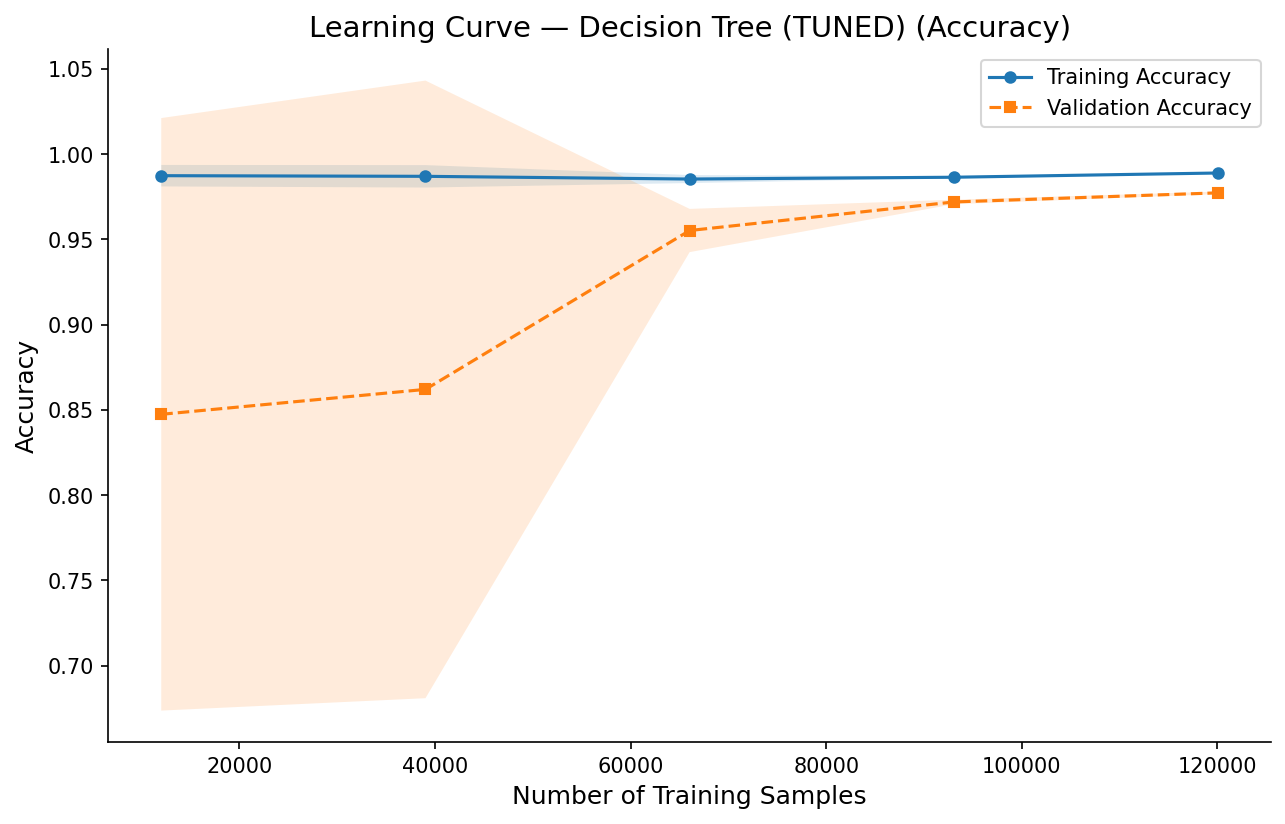

In [ ]:

# LEARNING CURVE — TUNED DECISION TREE 
from sklearn.tree import DecisionTreeClassifier

dt_tuned = DecisionTreeClassifier(
    max_depth=25,
    max_features=None,
    min_samples_leaf=5,
    random_state=42
)

plot_learning_curve(
    dt_tuned,
    X_train_bal,
    y_train_bal,
    title="Learning Curve — Decision Tree (TUNED) (Accuracy)",
    scoring="accuracy"
)


XGBoost

In [ ]:
# XGBoost
import xgboost as xgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

xgb_classifier = xgb.XGBClassifier()

xgb_classifier.fit(X_train_bal, y_train_bal)

y_pred = xgb_classifier.predict(X_test_pp)

accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print("Accuracy of XGBoost:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", report)


Accuracy of XGBoost: 0.9670056396820462
Confusion Matrix:
 [[18190   571]
 [  172  3586]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9906    0.9696    0.9800     18761
           1     0.8626    0.9542    0.9061      3758

    accuracy                         0.9670     22519
   macro avg     0.9266    0.9619    0.9431     22519
weighted avg     0.9693    0.9670    0.9677     22519



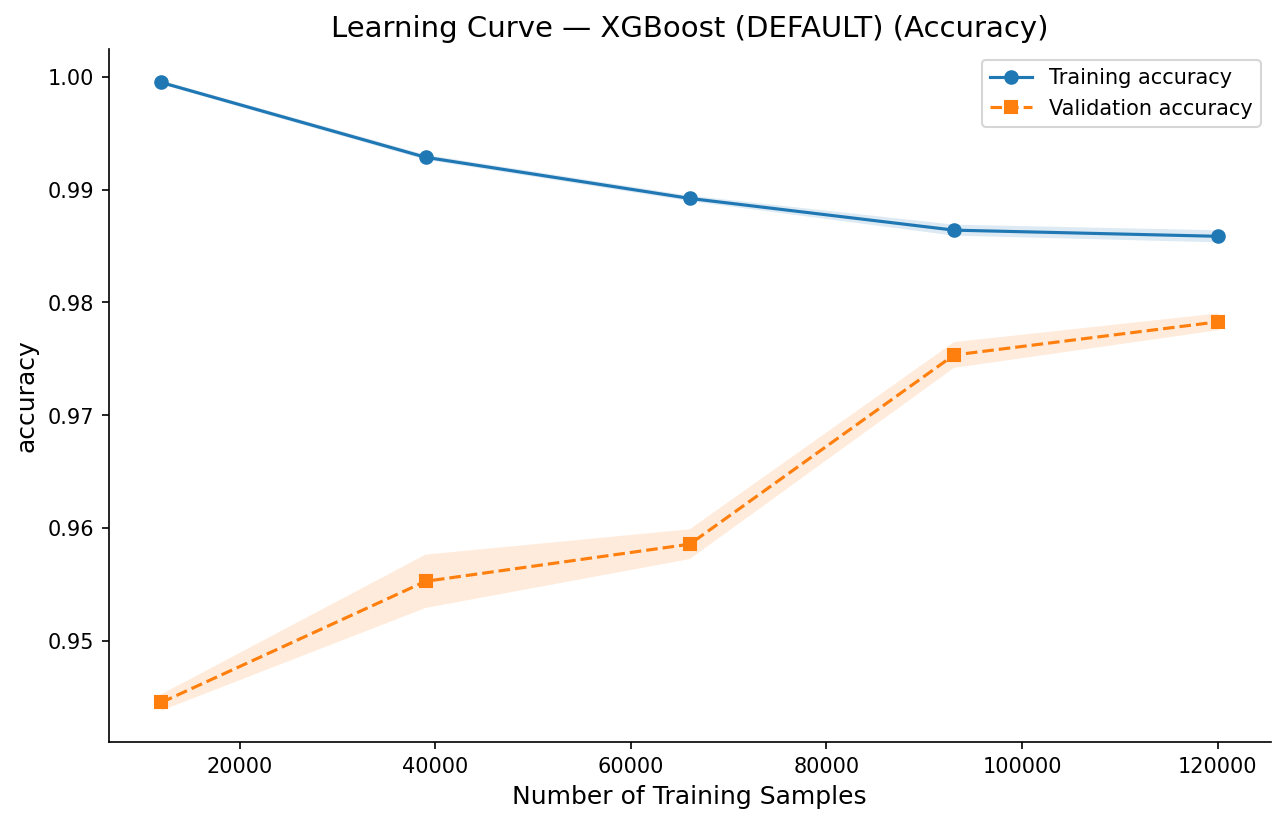

In [ ]:
# 1) Learning curve — XGBoost (base)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, StratifiedKFold
import xgboost as xgb

def plot_learning_curve(estimator, X, y, title, scoring="accuracy", cv_splits=5):
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
    )

    train_mean = train_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_mean   = val_scores.mean(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, marker="o", label=f"Training {scoring}")
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)
    plt.plot(train_sizes, val_mean, marker="s", linestyle="--", label=f"Validation {scoring}")
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.15)
    plt.title(title)
    plt.xlabel("Number of Training Samples")
    plt.ylabel(scoring)
    plt.grid()
    plt.legend(loc="best")
    plt.show()

xgb_default = xgb.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric="logloss"
)

plot_learning_curve(
    estimator=xgb_default,
    X=X_train_bal,
    y=y_train_bal,
    title="Learning Curve — XGBoost (DEFAULT) (Accuracy)",
    scoring="accuracy"
)


In [ ]:
# Define the XGBClassifier
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, make_scorer

xgb_classifier = xgb.XGBClassifier()

# Define the parameter grid for GridSearchCV
param_grid = {
    'learning_rate': [0.160, 0.076],
    'n_estimators': [200, 380],
    'max_depth': [9],
    'subsample': [1, 0.641],
    'gamma': [0.32, 0.779],
    'min_child_weight': [0, 1]
}

# Define the scoring metric
scoring = {'Accuracy': make_scorer(accuracy_score)}

# Create the GridSearchCV object
grid_search = GridSearchCV(
    estimator=xgb_classifier,
    param_grid=param_grid,
    scoring=scoring,
    refit='Accuracy',
    cv=3,
    verbose=1,
    n_jobs=-1
)

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train_bal, y_train_bal)

# Get the best parameters and model
best_params = grid_search.best_params_
best_xgb_classifier = grid_search.best_estimator_

print("Best Hyperparameters:", best_params)

# Make predictions on the test data using the best model
y_pred = best_xgb_classifier.predict(X_test_pp)

# Evaluate the classifier's accuracy, confusion matrix, and classification report
accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print("Accuracy:", accuracy)
print("Confusion Matrix:\n", confusion)
print("Classification Report:\n", report)


Fitting 3 folds for each of 32 candidates, totalling 96 fits
Best Hyperparameters: {'gamma': 0.32, 'learning_rate': 0.16, 'max_depth': 9, 'min_child_weight': 0, 'n_estimators': 380, 'subsample': 0.641}
Accuracy: 0.9741995648119366
Confusion Matrix:
 [[18459   302]
 [  279  3479]]
Classification Report:
               precision    recall  f1-score   support

           0     0.9851    0.9839    0.9845     18761
           1     0.9201    0.9258    0.9229      3758

    accuracy                         0.9742     22519
   macro avg     0.9526    0.9548    0.9537     22519
weighted avg     0.9743    0.9742    0.9742     22519



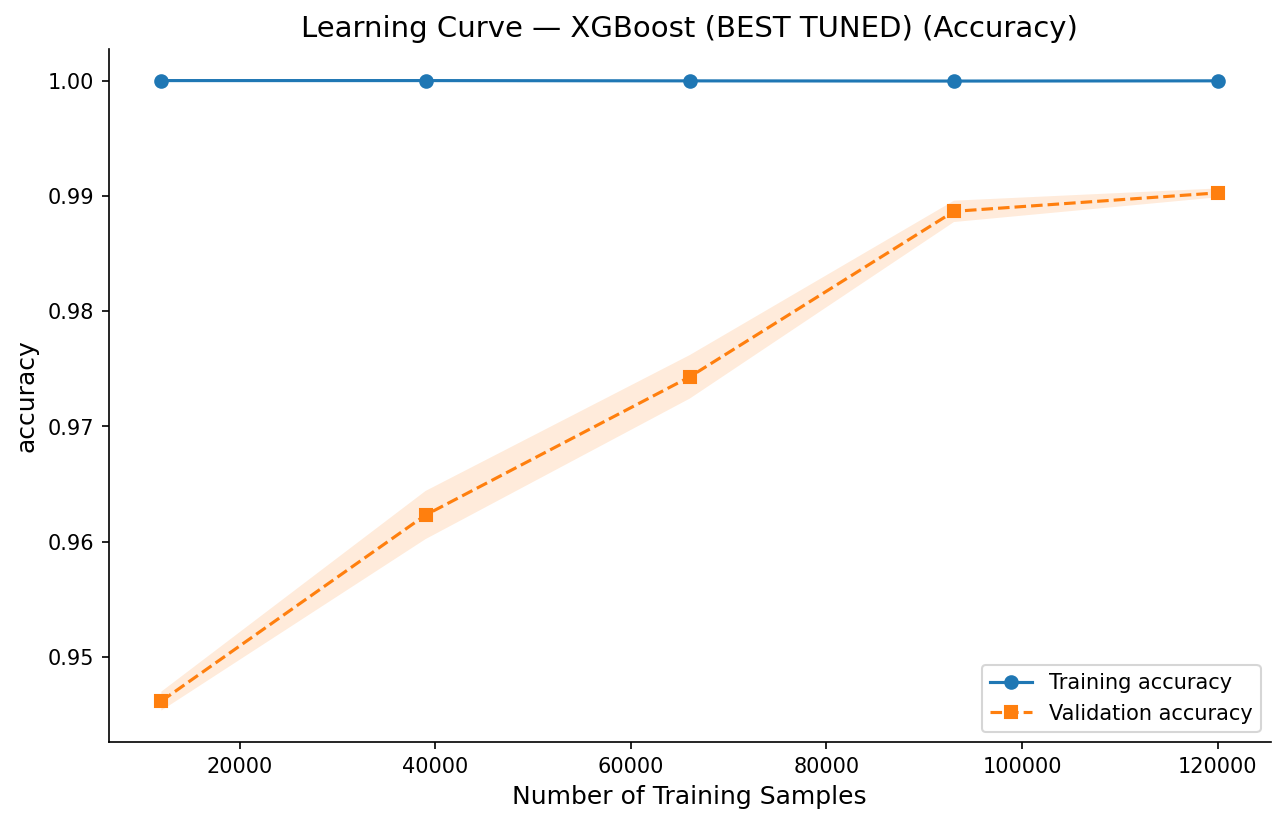

In [ ]:
# 2) Learning curve — XGBoost (TUNED / BEST from GridSearchCV)

plot_learning_curve(
    estimator=best_xgb_classifier,
    X=X_train_bal,
    y=y_train_bal,
    title="Learning Curve — XGBoost (BEST TUNED) (Accuracy)",
    scoring="accuracy"
)


XGBoost Feature Importance

Top 30 XGBoost Importances (GAIN):
                                           feature  importance_gain
                                   num__study_load      1491.818726
                                   cat__major_Arts       495.694458
                              cat__region_Scotland       492.503632
                                 num__stress_level       335.613556
                          num__study_hours_per_day       273.842316
                             num__motivation_level       211.747345
                              cat__imd_band_20-30%        89.499420
        cat__parental_education_level_Some College        87.457703
                                  num__screen_time        54.358372
                       cat__study_environment_Dorm        38.773056
                                     num__n_assess        14.541582
      cat__highest_education_A Level or Equivalent        12.769105
                           num__exam_anxiety_score        11.131994
             

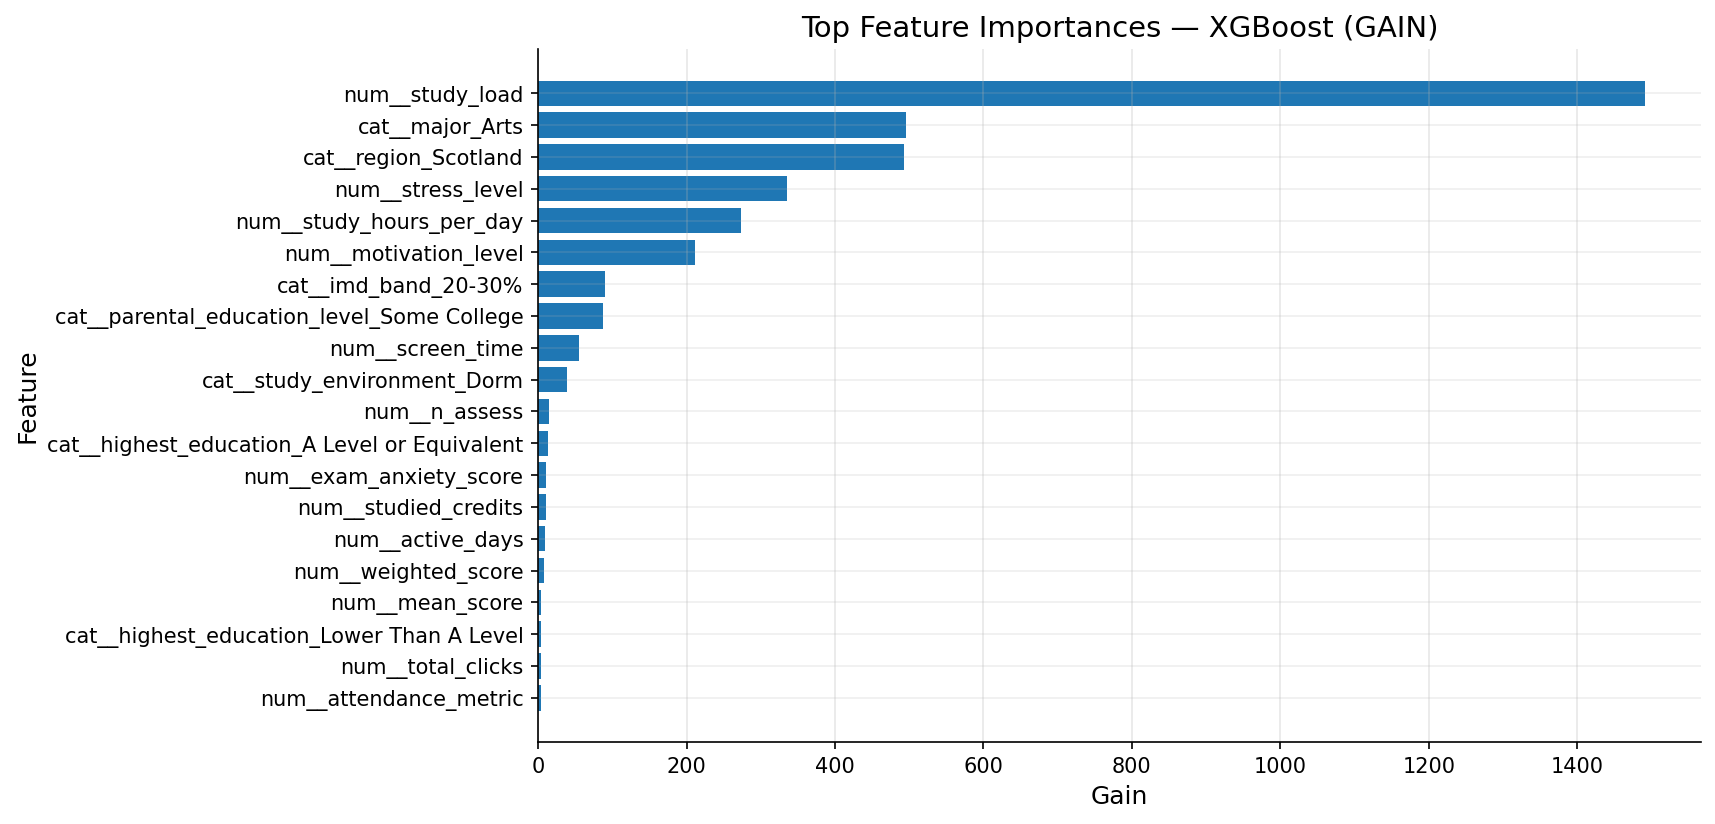

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

model = best_xgb_classifier 

feature_names = preprocess.get_feature_names_out()


booster = model.get_booster()
score_gain = booster.get_score(importance_type="gain")  # gain is best for interpretation

# convert to dataframe aligned with preprocess columns
rows = []
for k, v in score_gain.items():
    idx = int(k[1:])  # "f123" -> 123
    rows.append((feature_names[idx], v))

fi_xgb = pd.DataFrame(rows, columns=["feature","importance_gain"]).sort_values("importance_gain", ascending=False)

print("Top 30 XGBoost Importances (GAIN):")
print(fi_xgb.head(30).to_string(index=False))
top_n = 20
fi_top = fi_xgb.head(top_n)

plt.figure(figsize=(10,6))
plt.barh(fi_top["feature"][::-1], fi_top["importance_gain"][::-1])
plt.title("Top Feature Importances — XGBoost (GAIN)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


Lightgbm

In [ ]:
# 0) Helper: wrap sparse matrix into pandas with feature names 
import pandas as pd

feature_names = preprocess.get_feature_names_out()

def to_df(X, feature_names):
    # Works for sparse or dense
    if hasattr(X, "toarray"):
        X = X.toarray()
    return pd.DataFrame(X, columns=feature_names)

X_train_bal_df = to_df(X_train_bal, feature_names)
X_test_pp_df   = to_df(X_test_pp, feature_names)

print("X_train_bal_df:", X_train_bal_df.shape)
print("X_test_pp_df  :", X_test_pp_df.shape)


X_train_bal_df: (150084, 96)
X_test_pp_df  : (22519, 96)


In [ ]:
# 15) LightGBM Training & Evaluation (BASE)
import lightgbm as lgb
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

lgb_base = lgb.LGBMClassifier(random_state=42)
lgb_base.fit(X_train_bal_df, y_train_bal)

y_pred = lgb_base.predict(X_test_pp_df)

accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print(f"Accuracy of LightGBM (BASE): {accuracy}")
print(f"Confusion Matrix:\n{confusion}")
print(f"Classification Report:\n{report}")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 75042, number of negative: 75042
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3798
[LightGBM] [Info] Number of data points in the train set: 150084, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Accuracy of LightGBM (BASE): 0.9624761312669301
Confusion Matrix:
[[18049   712]
 [  133  3625]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9927    0.9620    0.9771     18761
           1     0.8358    0.9646    0.8956      3758

    accuracy                         0.9625     22519
   macro avg     0.9143    0.9633    0.9364     22519
weighted avg     0.9665 

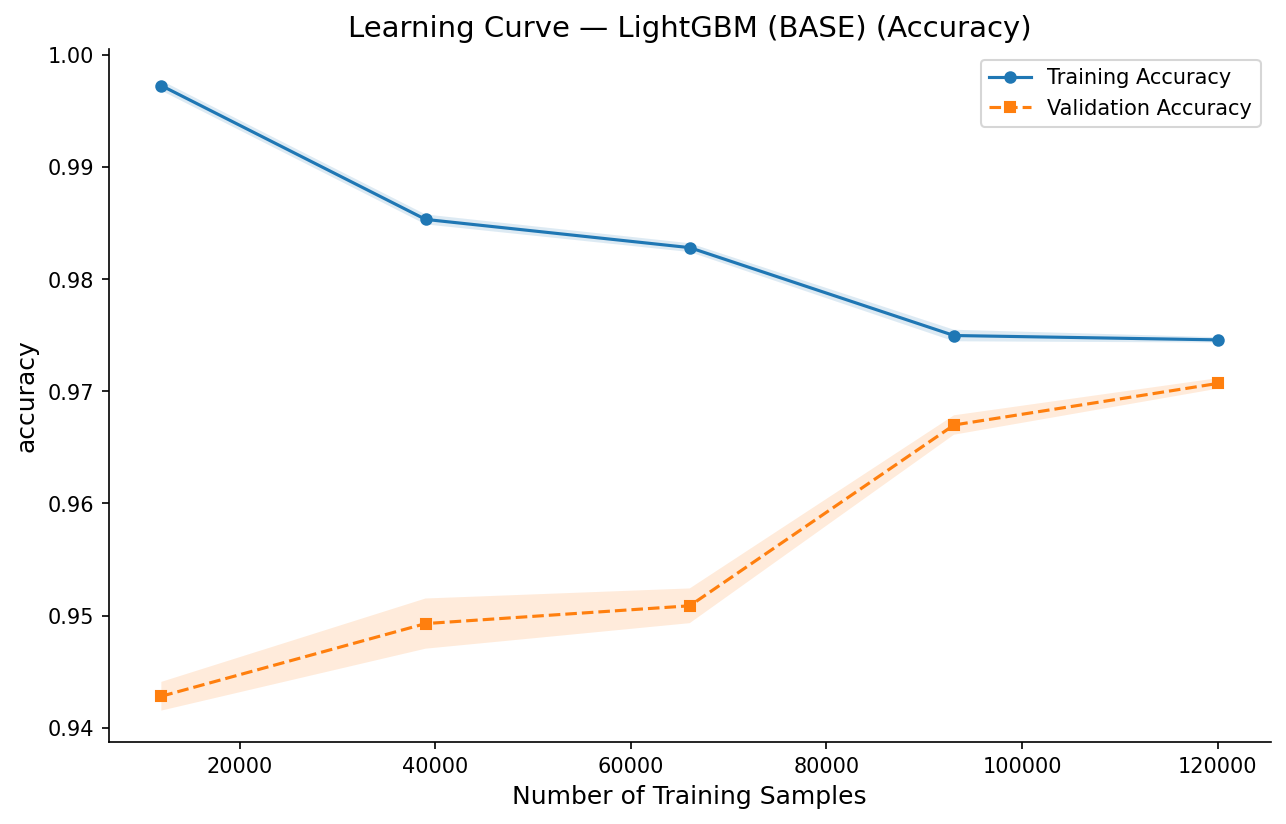

In [ ]:
# Learning Curve — LightGBM (BASE) (Accuracy)
from sklearn.model_selection import learning_curve, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curve(model, X, y, title, scoring="accuracy"):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    test_mean  = np.mean(test_scores, axis=1)
    test_std   = np.std(test_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, train_mean, marker='o', markersize=5, label='Training Accuracy')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.15)

    plt.plot(train_sizes, test_mean, linestyle='--', marker='s', markersize=5, label='Validation Accuracy')
    plt.fill_between(train_sizes, test_mean-test_std, test_mean+test_std, alpha=0.15)

    plt.title(title)
    plt.xlabel('Number of Training Samples')
    plt.ylabel(scoring)
    plt.legend(loc='upper right')
    plt.grid()
    plt.show()

plot_learning_curve(
    lgb.LGBMClassifier(random_state=42),
    X_train_bal_df,
    y_train_bal,
    title="Learning Curve — LightGBM (BASE) (Accuracy)",
    scoring="accuracy"
)


In [ ]:
# 16) GridSearchCV for LightGBM Hyperparameter Tuning 
from sklearn.model_selection import GridSearchCV
import lightgbm as lgb

lgb_clf = lgb.LGBMClassifier(random_state=42)

param_grid = {
    'num_leaves': [35, 40],
    'max_bin': [400, 450],
    'learning_rate': [0.01, 0.1],
    'n_estimators': [200, 300]  
}

grid_search = GridSearchCV(
    estimator=lgb_clf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_bal_df, y_train_bal)

print("Best Hyperparameters:", grid_search.best_params_)
best_lgb = grid_search.best_estimator_


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 75042, number of negative: 75042
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.035325 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5358
[LightGBM] [Info] Number of data points in the train set: 150084, number of used features: 96
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Best Hyperparameters: {'learning_rate': 0.1, 'max_bin': 450, 'n_estimators': 300, 'num_leaves': 40}


Accuracy of LightGBM (TUNED): 0.9687819174918957
Confusion Matrix:
[[18262   499]
 [  204  3554]]
Classification Report:
              precision    recall  f1-score   support

           0     0.9890    0.9734    0.9811     18761
           1     0.8769    0.9457    0.9100      3758

    accuracy                         0.9688     22519
   macro avg     0.9329    0.9596    0.9456     22519
weighted avg     0.9703    0.9688    0.9692     22519



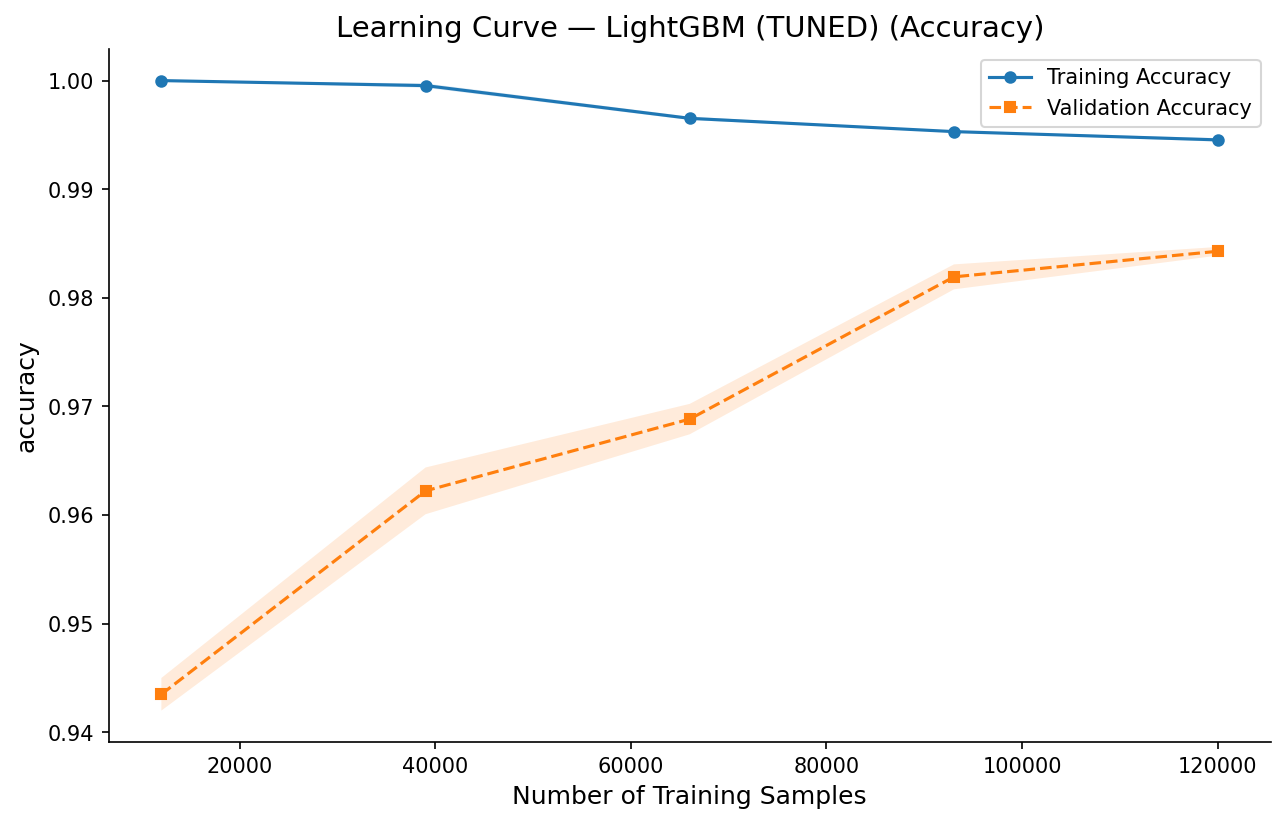

In [ ]:
# 17) Train LightGBM with Best Hyperparameters + Evaluation + Learning Curve
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = best_lgb.predict(X_test_pp_df)

accuracy = accuracy_score(y_test, y_pred)
confusion = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred, digits=4)

print(f"Accuracy of LightGBM (TUNED): {accuracy}")
print(f"Confusion Matrix:\n{confusion}")
print(f"Classification Report:\n{report}")

plot_learning_curve(
    best_lgb,
    X_train_bal_df,
    y_train_bal,
    title="Learning Curve — LightGBM (TUNED) (Accuracy)",
    scoring="accuracy"
)


Lightgbm feature importance

Top 30 LightGBM Importances (GAIN):
                                     feature  importance_gain
                        cat__region_Scotland    279450.832115
                             num__study_load    158815.662067
                           num__stress_level    109348.623307
                            num__active_days     85849.702017
                               num__n_assess     77677.605823
                        cat__imd_band_20-30%     58391.949172
                       num__motivation_level     56575.922243
                        num__studied_credits     38284.550445
                             cat__major_Arts     33845.229963
                             num__mean_score     28392.038598
                         num__weighted_score     23822.729109
                      num__attendance_metric     21193.548661
                           num__unique_sites     14753.232033
                             num__prior_perf     13930.696638
cat__highest_education_A Level or 

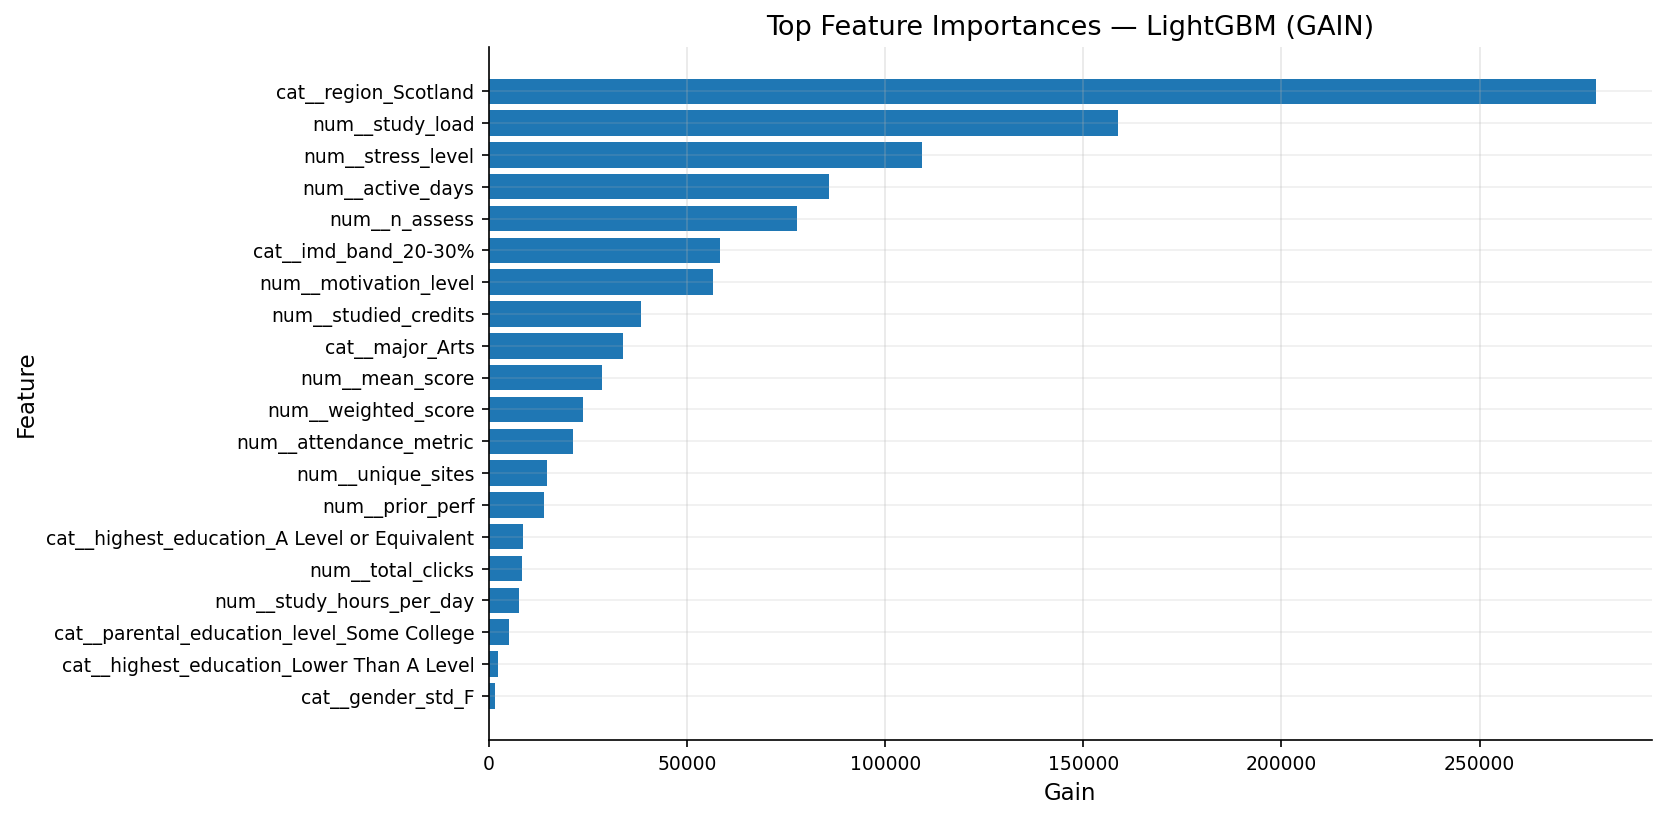

In [61]:
# LightGBM FEATURE IMPORTANCE (GAIN + SPLIT) + TOP 30 PRINT + PLOT
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


model = best_lgb  

feature_names = preprocess.get_feature_names_out()

# LightGBM returns importance aligned to feature order used in fit
gain_imp  = model.booster_.feature_importance(importance_type="gain")
split_imp = model.booster_.feature_importance(importance_type="split")

fi_lgb = pd.DataFrame({
    "feature": feature_names,
    "importance_gain": gain_imp,
}).sort_values("importance_gain", ascending=False)

print("Top 30 LightGBM Importances (GAIN):")
print(fi_lgb[["feature","importance_gain"]].head(30).to_string(index=False))


# Plot top N (GAIN)
top_n = 20
fi_top = fi_lgb.head(top_n).copy()

plt.figure(figsize=(10,6))
plt.barh(fi_top["feature"][::-1], fi_top["importance_gain"][::-1])
plt.title("Top Feature Importances — LightGBM (GAIN)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


Load model

In [ ]:

import os, joblib

MODEL_FILE = os.path.join(os.getcwd(), "dropout_risk_xgb_bundle.pkl")

bundle = {
    "model_name": "XGBoost (tuned)",
    "model": best_xgb_classifier,
    "preprocess": preprocess,
    "raw_feature_columns": list(X_train.columns),
    "cat_cols": cat_cols,
    "num_cols": num_cols,
}
joblib.dump(bundle, MODEL_FILE)
print("✅ Saved:", MODEL_FILE)


✅ Saved: c:\Users\User\Desktop\Too Lik Heng-TP074610-APU3F2209CS(DA)-FYP\dropout_risk_xgb_bundle.pkl
